<a href="https://colab.research.google.com/github/antonellagambarte/vision-por-computadoras-II/blob/main/03_entrega_final/04_modelos_con_features_saturacion_brillo_color.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Optimizado para Clasificación de Enfermedades en Plantas

Este notebook mejora el pipeline anterior con las siguientes optimizaciones:

1. **Eliminación de imágenes duplicadas**: Detectamos y removemos imágenes duplicadas usando hashing perceptual para evitar sesgos en el entrenamiento
2. **Data Augmentation en clases subrepresentadas**: Aplicamos aumento de datos específicamente en las clases con menor representación para balancear el dataset
3. **Búsqueda de hiperparámetros con Optuna**: Optimizamos automáticamente learning rate, batch size, y arquitectura del clasificador
4. Se agrgan features de color, brillo, saturación
**Modelos a comparar:**
- MobileNetV2
- MobileNetV3

**Objetivo**: Maximizar recall y accuracy mientras mantenemos el modelo lo suficientemente ligero para deployment móvil.


In [1]:
test_execution = False


## Imports y Configuración Inicial


In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 26.4 MB/s eta 0:00:00


In [3]:
import gdown
import zipfile
import os
import time
import copy
import hashlib
from pathlib import Path
from collections import Counter, defaultdict
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import cv2

from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score,
                            f1_score, roc_curve, auc, precision_recall_curve,
                            average_precision_score)
from sklearn.preprocessing import LabelBinarizer

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torch.ao.quantization import get_default_qconfig_mapping, get_default_qat_qconfig_mapping
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx, prepare_qat_fx

import optuna
from optuna.trial import TrialState
import warnings

# Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Para asegurar reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Silenciar warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


Usando dispositivo: cuda


## Carga del Dataset


In [4]:
url = "https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri"
output = "archivo.zip"
destino = "datos_zip"

def zip_is_valid(path):
    if not os.path.isfile(path) or os.path.getsize(path) == 0:
        return False
    try:
        with zipfile.ZipFile(path, 'r') as z:
            return z.testzip() is None
    except Exception as e:
        print("Error:", e)
        return False

# Descargar solo si no existe o si el zip es inválido
if not zip_is_valid(output):
    print("Descargando dataset...")
    gdown.download(url, output, quiet=False, fuzzy=True)
else:
    print(f"'{output}' ya existe.")

os.makedirs(destino, exist_ok=True)
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

print("Archivo extraído correctamente en:", destino)


Descargando dataset...


Downloading...
From (original): https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri
From (redirected): https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri&confirm=t&uuid=63983ac0-3d3d-4590-941c-536b3d1a53aa
To: /content/archivo.zip
100%|██████████| 2.19G/2.19G [00:33<00:00, 65.1MB/s]


Archivo extraído correctamente en: datos_zip


## 1. Detección y Eliminación de Duplicados

Utilizamos hashing perceptual (pHash) para detectar imágenes duplicadas o casi idénticas.
Esto previene que el modelo memorice la misma imagen y mejora la generalización.


In [5]:
def compute_file_hash(image_path, algo="md5", chunk_size=8192):
    """
    Calcula un hash exacto del archivo de imagen.
    Esto detecta imágenes idénticas (bit a bit).
    """
    hash_func = hashlib.md5() if algo == "md5" else hashlib.sha256()

    try:
        with open(image_path, "rb") as f:
            while chunk := f.read(chunk_size):
                hash_func.update(chunk)
        return hash_func.hexdigest()
    except Exception as e:
        print(f"Error procesando {image_path}: {e}")
        return None

def find_duplicate_images(data_dir, algo="md5"):
    """
    Encuentra imágenes duplicadas exactas (mismo contenido).
    Retorna dict {hash: [paths]} donde paths > 1 son duplicados.
    """
    hash_dict = defaultdict(list)

    print("Calculando hashes exactos...")
    for root, dirs, files in os.walk(data_dir):
        for file in tqdm(files, desc=f"Procesando {os.path.basename(root)}"):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)
                img_hash = compute_file_hash(file_path, algo)

                if img_hash:
                    hash_dict[img_hash].append(file_path)

    # Filtrar solo duplicados
    duplicates = {h: paths for h, paths in hash_dict.items() if len(paths) > 1}
    return duplicates


def remove_duplicates(data_dir, duplicates_dict):
    """
    Elimina imágenes duplicadas, manteniendo solo una copia de cada grupo.
    """
    removed_count = 0

    for img_hash, paths in duplicates_dict.items():
        # Mantener la primera imagen, eliminar el resto
        for path_to_remove in paths[1:]:
            try:
                os.remove(path_to_remove)
                removed_count += 1
            except Exception as e:
                print(f"Error eliminando {path_to_remove}: {e}")

    return removed_count


In [6]:
# Ejecutar detección y eliminación de duplicados
data_dir = "datos_zip/plantvillage dataset/color"

print("="*70)
print("PASO 1: DETECCIÓN Y ELIMINACIÓN DE DUPLICADOS")
print("="*70)

duplicates = find_duplicate_images(data_dir)

if duplicates:
    print(f"\n📊 Se encontraron {len(duplicates)} grupos de imágenes duplicadas")
    print(f"   Total de imágenes duplicadas: {sum(len(paths)-1 for paths in duplicates.values())}")

    # Mostrar algunos ejemplos
    print("\n📋 Primeros 5 grupos de duplicados:")
    for i, (img_hash, paths) in enumerate(list(duplicates.items())[:5]):
        print(f"  Grupo {i+1}: {len(paths)} copias")
        for path in paths[:3]:  # Mostrar max 3 paths
            print(f"    - {path}")

    # Eliminar duplicados
    print("\n🗑️ Eliminando duplicados...")
    removed = remove_duplicates(data_dir, duplicates)
    print(f"✅ Se eliminaron {removed} imágenes duplicadas")
else:
    print("✅ No se encontraron duplicados en el dataset")


PASO 1: DETECCIÓN Y ELIMINACIÓN DE DUPLICADOS
Calculando hashes exactos...


Procesando color: 0it [00:00, ?it/s]
Procesando Corn_(maize)___Common_rust_: 100%|██████████| 1192/1192 [00:00<00:00, 19935.84it/s]
Procesando Orange___Haunglongbing_(Citrus_greening): 100%|██████████| 5507/5507 [00:00<00:00, 22274.97it/s]
Procesando Pepper,_bell___Bacterial_spot: 100%|██████████| 997/997 [00:00<00:00, 17077.10it/s]
Procesando Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 100%|██████████| 1076/1076 [00:00<00:00, 16701.65it/s]
Procesando Apple___healthy: 100%|██████████| 1645/1645 [00:00<00:00, 19683.20it/s]
Procesando Tomato___Tomato_Yellow_Leaf_Curl_Virus: 100%|██████████| 5357/5357 [00:00<00:00, 19563.31it/s]
Procesando Grape___Esca_(Black_Measles): 100%|██████████| 1383/1383 [00:00<00:00, 16130.23it/s]
Procesando Tomato___Spider_mites Two-spotted_spider_mite: 100%|██████████| 1676/1676 [00:00<00:00, 15480.27it/s]
Procesando Apple___Apple_scab: 100%|██████████| 630/630 [00:00<00:00, 16559.16it/s]
Procesando Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 100%|█████


📊 Se encontraron 21 grupos de imágenes duplicadas
   Total de imágenes duplicadas: 21

📋 Primeros 5 grupos de duplicados:
  Grupo 1: 2 copias
    - datos_zip/plantvillage dataset/color/Apple___healthy/1ab5e019-e5f0-4d8e-a252-94cb0aab8b0a___RS_HL 6269.JPG
    - datos_zip/plantvillage dataset/color/Apple___healthy/3673d121-b5de-481c-b057-d4ee5b4959b1___RS_HL 6269.JPG
  Grupo 2: 2 copias
    - datos_zip/plantvillage dataset/color/Apple___healthy/5192db55-4aa7-421c-92d4-c2dac79e7379___RS_HL 6273.JPG
    - datos_zip/plantvillage dataset/color/Apple___healthy/9b75de13-d4b0-4b3f-988c-3e9926eef957___RS_HL 6273.JPG
  Grupo 3: 2 copias
    - datos_zip/plantvillage dataset/color/Apple___healthy/fdbfa6f7-f887-442d-8df1-1f0cf839fc4d___RS_HL 6274.JPG
    - datos_zip/plantvillage dataset/color/Apple___healthy/f2cda910-55c7-46d7-b1a2-9a3bb9792148___RS_HL 6274.JPG
  Grupo 4: 2 copias
    - datos_zip/plantvillage dataset/color/Apple___healthy/13298d36-4425-437d-ae8e-c7d70e200084___RS_HL 6271.JPG
    - 

## 2. Análisis de Distribución de Clases

Analizamos cuántas imágenes tiene cada clase para identificar desbalance.


PASO 2: ANÁLISIS DE DISTRIBUCIÓN DE CLASES

📊 Dataset Statistics:
   Total de clases: 38
   Total de imágenes: 54284
   Promedio por clase: 1428.5

📉 Top 10 clases con MENOS imágenes:
   Potato___healthy                                  :   152 imágenes (0.28%)
   Apple___Cedar_apple_rust                          :   275 imágenes (0.51%)
   Peach___healthy                                   :   360 imágenes (0.66%)
   Raspberry___healthy                               :   371 imágenes (0.68%)
   Tomato___Tomato_mosaic_virus                      :   373 imágenes (0.69%)
   Grape___healthy                                   :   423 imágenes (0.78%)
   Strawberry___healthy                              :   456 imágenes (0.84%)
   Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:   513 imágenes (0.95%)
   Apple___Black_rot                                 :   621 imágenes (1.14%)
   Apple___Apple_scab                                :   630 imágenes (1.16%)

📈 Top 10 clases con MÁS imágenes:
 

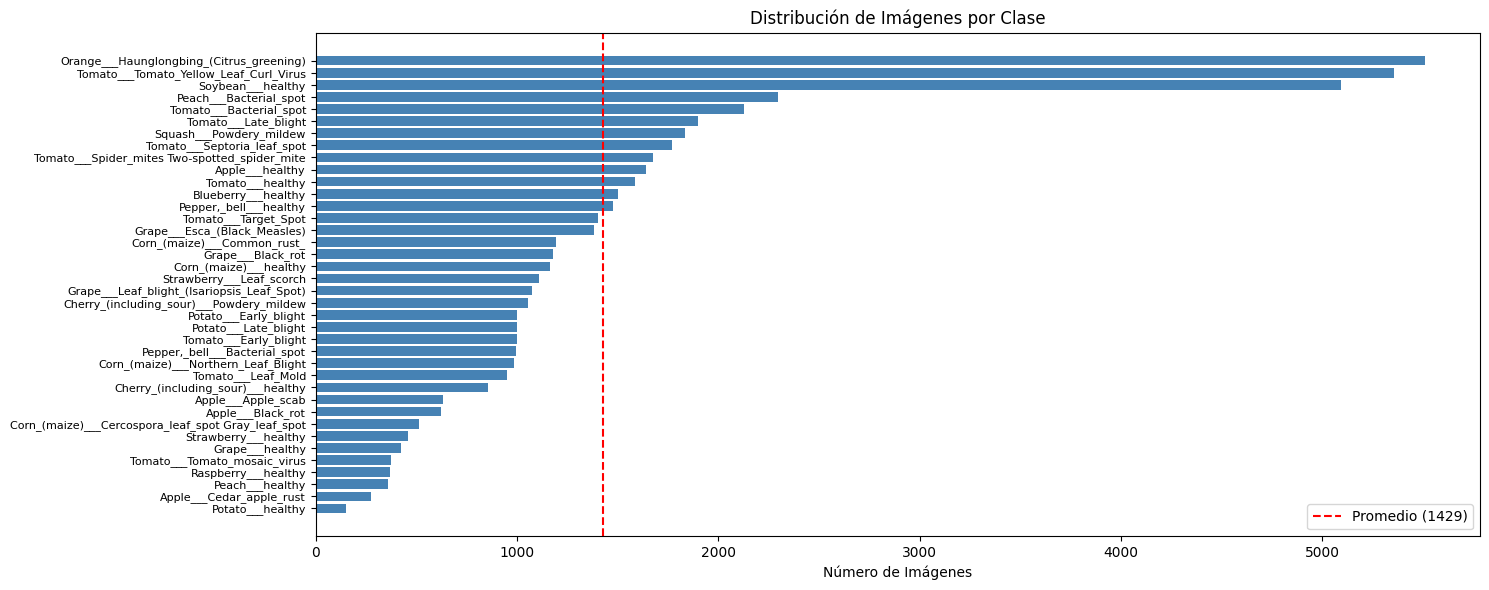


⚠️ Clases con representación baja (< 80% del promedio):
   20 clases requieren augmentation
   Potato___healthy                                  :   152 → necesita ~ 990 imágenes más
   Apple___Cedar_apple_rust                          :   275 → necesita ~ 867 imágenes más
   Peach___healthy                                   :   360 → necesita ~ 782 imágenes más
   Raspberry___healthy                               :   371 → necesita ~ 771 imágenes más
   Tomato___Tomato_mosaic_virus                      :   373 → necesita ~ 769 imágenes más
   Grape___healthy                                   :   423 → necesita ~ 719 imágenes más
   Strawberry___healthy                              :   456 → necesita ~ 686 imágenes más
   Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:   513 → necesita ~ 629 imágenes más
   Apple___Black_rot                                 :   621 → necesita ~ 521 imágenes más
   Apple___Apple_scab                                :   630 → necesita ~ 512 imágenes m

In [7]:
def analyze_class_distribution(data_dir):
    """
    Analiza la distribución de imágenes por clase.
    """
    class_counts = {}

    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            img_files = [f for f in os.listdir(class_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            class_counts[class_name] = len(img_files)

    return class_counts

print("="*70)
print("PASO 2: ANÁLISIS DE DISTRIBUCIÓN DE CLASES")
print("="*70)

class_distribution = analyze_class_distribution(data_dir)
total_images = sum(class_distribution.values())
num_classes = len(class_distribution)

print(f"\n📊 Dataset Statistics:")
print(f"   Total de clases: {num_classes}")
print(f"   Total de imágenes: {total_images}")
print(f"   Promedio por clase: {total_images / num_classes:.1f}")

# Ordenar por cantidad de imágenes
sorted_classes = sorted(class_distribution.items(), key=lambda x: x[1])

print(f"\n📉 Top 10 clases con MENOS imágenes:")
for class_name, count in sorted_classes[:10]:
    print(f"   {class_name:50s}: {count:5d} imágenes ({count/total_images*100:.2f}%)")

print(f"\n📈 Top 10 clases con MÁS imágenes:")
for class_name, count in sorted_classes[-10:]:
    print(f"   {class_name:50s}: {count:5d} imágenes ({count/total_images*100:.2f}%)")

# Visualizar distribución
plt.figure(figsize=(15, 6))
classes_sorted = [c[0] for c in sorted_classes]
counts_sorted = [c[1] for c in sorted_classes]

plt.barh(range(len(classes_sorted)), counts_sorted, color='steelblue')
plt.yticks(range(len(classes_sorted)), classes_sorted, fontsize=8)
plt.xlabel('Número de Imágenes')
plt.title('Distribución de Imágenes por Clase')
plt.axvline(x=total_images/num_classes, color='red', linestyle='--',
            label=f'Promedio ({total_images/num_classes:.0f})')
plt.legend()
plt.tight_layout()
plt.show()

# Identificar clases con menos representación (< 80% del promedio)
threshold = 0.8 * (total_images / num_classes)
underrepresented_classes = {c: count for c, count in class_distribution.items()
                           if count < threshold}

print(f"\n⚠️ Clases con representación baja (< 80% del promedio):")
print(f"   {len(underrepresented_classes)} clases requieren augmentation")
for class_name, count in sorted(underrepresented_classes.items(), key=lambda x: x[1]):
    needed = int(threshold - count)
    print(f"   {class_name:50s}: {count:5d} → necesita ~{needed:4d} imágenes más")


## 3. Data Augmentation para Clases Desbalanceadas

Aplicamos augmentation selectivo solo a las clases con menor representación.
Esto balancea el dataset sin sobre-aumentar las clases ya bien representadas.


In [8]:
def create_augmentation_pipeline():
    """
    Crea un pipeline de augmentation. Se aplican: rotación de hasta 20 grados en amabas orientaciones;
    espejado de imagenes (horizontal y vertical); modificacion de brillo, contraste y saturación en un 20%;
    se mueve la imagen aleatoriamente en un 10% (horizontal y verticalmente); recorte aleatorio de entre un 80 y un 100%

    """
    return transforms.Compose([
        transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    ])

def augment_underrepresented_classes(data_dir, class_distribution, target_percentile=0.8):
    """
    Aumenta las clases con menos representación hasta alcanzar un umbral objetivo.

    Args:
        data_dir: Directorio raíz del dataset
        class_distribution: Dict con {clase: cantidad}
        target_percentile: Percentil objetivo (0.8 = 80% del promedio)
    """
    total_images = sum(class_distribution.values())
    num_classes = len(class_distribution)
    target_count = int(target_percentile * (total_images / num_classes))

    augmentation = create_augmentation_pipeline()
    total_generated = 0

    print("="*70)
    print("PASO 3: DATA AUGMENTATION SELECTIVO")
    print("="*70)
    print(f"Objetivo: ~{target_count} imágenes por clase")

    for class_name, current_count in tqdm(class_distribution.items(), desc="Procesando clases"):
        if current_count >= target_count:
            continue  # Clase ya tiene suficientes imágenes

        needed = target_count - current_count
        class_path = os.path.join(data_dir, class_name)

        # Obtener todas las imágenes de esta clase
        img_files = [f for f in os.listdir(class_path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not img_files:
            continue

        # Generar data augmentation
        generated = 0
        while generated < needed:
            # Seleccionar imagen origen aleatoria
            source_img_name = np.random.choice(img_files)
            source_img_path = os.path.join(class_path, source_img_name)

            try:
                # Cargar y aumentar
                img = Image.open(source_img_path).convert('RGB')
                augmented_img = augmentation(img)

                # Guardar con nombre único
                base_name = os.path.splitext(source_img_name)[0]
                aug_name = f"{base_name}_aug_{generated}.jpg"
                aug_path = os.path.join(class_path, aug_name)

                augmented_img.save(aug_path)
                generated += 1
                total_generated += 1

            except Exception as e:
                print(f"Error augmentando {source_img_path}: {e}")
                continue

        print(f"  ✓ {class_name:50s}: +{generated} imágenes ({current_count} → {current_count + generated})")

    print(f"\n✅ Data Augmentation completado: {total_generated} nuevas imágenes generadas")

    return total_generated


PASO 3: DATA AUGMENTATION SELECTIVO
Objetivo: ~1142 imágenes por clase


Procesando clases:   8%|▊         | 3/38 [00:00<00:10,  3.43it/s]

  ✓ Pepper,_bell___Bacterial_spot                     : +145 imágenes (997 → 1142)


Procesando clases:  11%|█         | 4/38 [00:01<00:10,  3.23it/s]

  ✓ Grape___Leaf_blight_(Isariopsis_Leaf_Spot)        : +66 imágenes (1076 → 1142)


...

  ✓ Peach___healthy                                   : +782 imágenes (360 → 1142)


Procesando clases:  97%|█████████▋| 37/38 [00:43<00:02,  2.33s/it]

  ✓ Apple___Cedar_apple_rust                          : +867 imágenes (275 → 1142)


Procesando clases: 100%|██████████| 38/38 [00:44<00:00,  1.17s/it]

  ✓ Cherry_(including_sour)___Powdery_mildew          : +90 imágenes (1052 → 1142)

✅ Data Augmentation completado: 8641 nuevas imágenes generadas

DISTRIBUCIÓN DESPUÉS DE AUGMENTATION

📊 Nuevas estadísticas:
   Total de imágenes: 62925 (antes: 54284, +8641)
   Promedio por clase: 1655.9


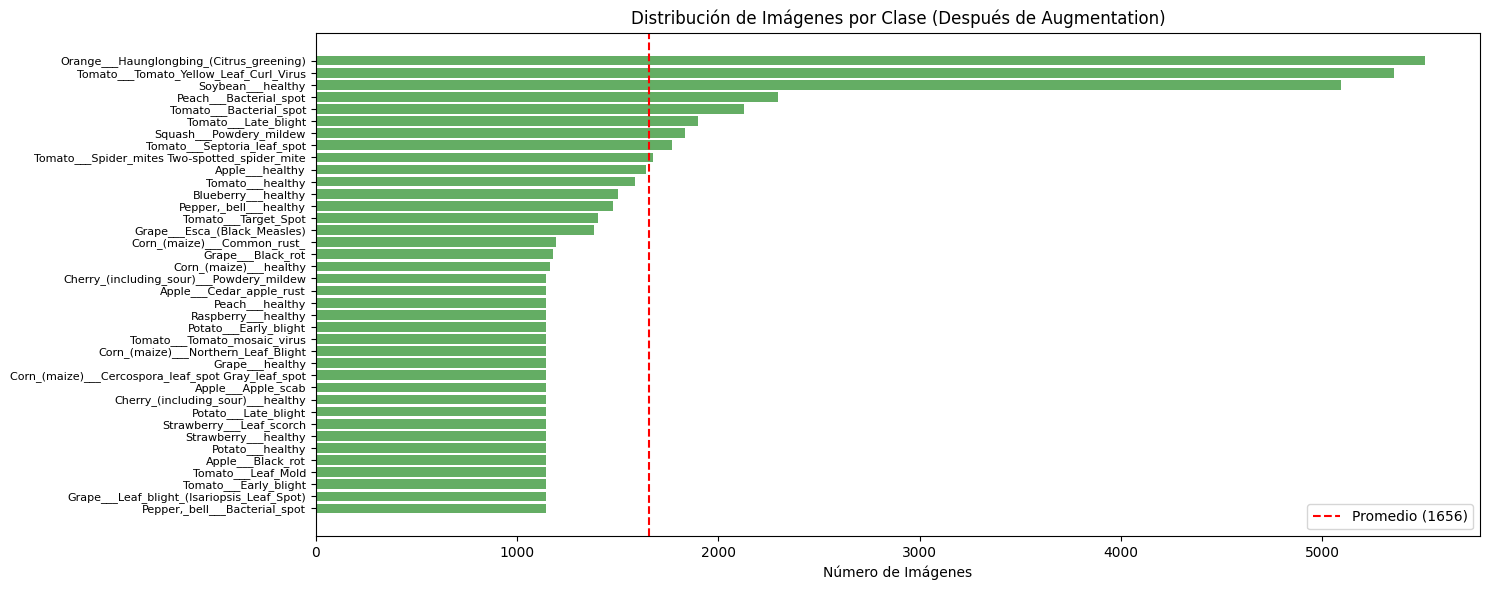

In [9]:
# Ejecutar data augmentation
generated_images = augment_underrepresented_classes(data_dir, class_distribution, target_percentile=0.8)

# Re-analizar distribución después del augmentation
print("\n" + "="*70)
print("DISTRIBUCIÓN DESPUÉS DE AUGMENTATION")
print("="*70)

new_distribution = analyze_class_distribution(data_dir)
new_total = sum(new_distribution.values())

print(f"\n📊 Nuevas estadísticas:")
print(f"   Total de imágenes: {new_total} (antes: {total_images}, +{new_total - total_images})")
print(f"   Promedio por clase: {new_total / num_classes:.1f}")

# Visualizar nueva distribución
plt.figure(figsize=(15, 6))
sorted_new = sorted(new_distribution.items(), key=lambda x: x[1])
classes_new = [c[0] for c in sorted_new]
counts_new = [c[1] for c in sorted_new]

plt.barh(range(len(classes_new)), counts_new, color='forestgreen', alpha=0.7)
plt.yticks(range(len(classes_new)), classes_new, fontsize=8)
plt.xlabel('Número de Imágenes')
plt.title('Distribución de Imágenes por Clase (Después de Augmentation)')
plt.axvline(x=new_total/num_classes, color='red', linestyle='--',
            label=f'Promedio ({new_total/num_classes:.0f})')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Preparación de Datos y Transformaciones


In [10]:
# Transformaciones para train (con augmentation adicional ligero)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Transformaciones para val y test (sin augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


Funciones de Extracción de Características Numéricas

In [11]:
import cv2
import numpy as np
from PIL import Image
import torch

def extract_saturation(image: Image.Image) -> float:
    """
    Calcula la saturación promedio de una imagen.
    Convierte la imagen a HSV y retorna la media del canal de saturación (S en HSV).
    """
    img_np = np.array(image.convert('RGB'))
    img_hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
    saturation = img_hsv[:, :, 1] # Canal S de HSV
    return float(np.mean(saturation))

def extract_brightness(image: Image.Image) -> float:
    """
    Calcula el brillo promedio de una imagen.
    Convierte la imagen a HSV y retorna la media del canal de valor (Value).
    """
    img_np = np.array(image.convert('RGB'))
    img_hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
    value = img_hsv[:, :, 2] # Canal V de HSV
    return float(np.mean(value))

def get_color_proportions(image: Image.Image) -> np.ndarray:
    """
    Calcula las proporciones de amarillo y verde en una imagen PIL.
    """
    try:
        img_np = np.array(image.convert('RGB'))
        img_hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

        # Definir rangos HSV para amarillo
        lower_yellow = np.array([20, 100, 100])
        upper_yellow = np.array([40, 255, 255])

        # Definir rangos HSV para verde
        lower_green = np.array([40, 40, 40])
        upper_green = np.array([80, 255, 255])

        mask_yellow = cv2.inRange(img_hsv, lower_yellow, upper_yellow)
        mask_green = cv2.inRange(img_hsv, lower_green, upper_green)

        # Considerar el total de píxeles de la imagen para la proporción
        total_pixels = img_np.shape[0] * img_np.shape[1]

        if total_pixels == 0:
            return np.array([0.0, 0.0])

        yellow_proportion = np.sum(mask_yellow > 0) / total_pixels
        green_proportion = np.sum(mask_green > 0) / total_pixels
        return np.array([yellow_proportion, green_proportion])
    except Exception as e:
        # print(f"Error en get_color_proportions: {e}") # Descomentar para depurar
        return np.array([0.0, 0.0])

def get_red_brown_stats(image: Image.Image) -> np.ndarray:
    """
    Calcula la proporción de rojo y marrón en una imagen PIL.
    """
    try:
        img_np = np.array(image.convert('RGB'))
        hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

        # Rangos HSV para rojo (dos segmentos en el círculo de matiz)
        lower_red1 = np.array([0, 80, 50])
        upper_red1 = np.array([10, 255, 255])
        lower_red2 = np.array([170, 80, 50])
        upper_red2 = np.array([180, 255, 255])

        # Rango HSV para marrón (ejemplo, puede requerir ajuste)
        lower_brown = np.array([10, 80, 20])
        upper_brown = np.array([25, 255, 200])

        mask_red = cv2.bitwise_or(cv2.inRange(hsv, lower_red1, upper_red1),
                                  cv2.inRange(hsv, lower_red2, upper_red2))
        mask_brown = cv2.inRange(hsv, lower_brown, upper_brown)

        total_pixels = img_np.shape[0] * img_np.shape[1]

        if total_pixels == 0:
            return np.array([0.0, 0.0])

        red_proportion = np.sum(mask_red > 0) / total_pixels
        brown_proportion = np.sum(mask_brown > 0) / total_pixels
        return np.array([red_proportion, brown_proportion])
    except Exception as e:
        # print(f"Error en get_red_brown_stats: {e}") # Descomentar para depurar
        return np.array([0.0, 0.0])

def extract_rgb_statistics_detailed(image: Image.Image) -> np.ndarray:
    """
    Calcula la media y la desviación estándar de cada canal RGB de una imagen.
    Retorna un vector de 6 valores: [mean_R, std_R, mean_G, std_G, mean_B, std_B].
    """
    img_np = np.array(image.convert('RGB'))
    mean_r, mean_g, mean_b = np.mean(img_np[:, :, 0]), np.mean(img_np[:, :, 1]), np.mean(img_np[:, :, 2])
    std_r, std_g, std_b = np.std(img_np[:, :, 0]), np.std(img_np[:, :, 1]), np.std(img_np[:, :, 2])
    return np.array([mean_r, std_r, mean_g, std_g, mean_b, std_b])

def extract_all_color_features(image: Image.Image) -> np.ndarray:
    """
    Combina todas las características de color: proporciones (amarillo, verde, rojo, marrón)
    y estadísticas RGB (media y std).
    Retorna un vector de 10 valores.
    """
    yellow_green_props = get_color_proportions(image)
    red_brown_props = get_red_brown_stats(image)
    rgb_stats_detailed = extract_rgb_statistics_detailed(image)

    combined_features = np.concatenate(
        (yellow_green_props, red_brown_props, rgb_stats_detailed)
    )
    return combined_features

# Definir la dimensión de las características numéricas combinadas (1 saturación + 1 brillo + 10 de all_color_features)
numerical_features_dim = 12

print("Funciones de extracción de características numéricas actualizadas. numerical_features_dim:"
      f" {numerical_features_dim}")


Funciones de extracción de características numéricas actualizadas. numerical_features_dim: 12


Clase Custom PlantImageDataset

In [12]:
from torch.utils.data import Dataset, Subset
from torchvision import datasets
from PIL import Image
import os
import torch

class PlantImageDataset(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base_dataset = base_dataset
        self.transform = transform

        if isinstance(base_dataset, Subset):
            self.samples = [(base_dataset.dataset.samples[i][0], base_dataset.dataset.samples[i][1]) for i in base_dataset.indices]
            self.classes = base_dataset.dataset.classes
        elif isinstance(base_dataset, datasets.ImageFolder):
            self.samples = base_dataset.samples
            self.classes = base_dataset.classes
        elif isinstance(base_dataset, PlantImageDataset):
            self.samples = base_dataset.samples
            self.classes = base_dataset.classes
            self.transform = base_dataset.transform
        else:
            raise TypeError("base_dataset debe ser torchvision.datasets.ImageFolder, torch.utils.data.Subset o PlantImageDataset")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        original_image = Image.open(img_path).convert('RGB')

        # Extraer características numéricas de la imagen original
        saturation = extract_saturation(original_image)
        brightness = extract_brightness(original_image)
        all_color_features = extract_all_color_features(original_image)

        # Concatenar todas las características numéricas en un tensor de PyTorch
        numerical_features = torch.tensor(
            [saturation, brightness] + all_color_features.tolist(),
            dtype=torch.float32
        )

        # Aplicar transformaciones visuales a la imagen
        transformed_image = self.transform(original_image) if self.transform else original_image

        return transformed_image, numerical_features, label

print("Clase PlantImageDataset definida y actualizada para las nuevas características de color.")

Clase PlantImageDataset definida y actualizada para las nuevas características de color.


## 5. Partición Estratificada del Dataset


In [13]:
def stratified_split_indices(indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=None):
    """
    Divide los índices de forma estratificada por clase.
    """
    if rng is None:
        rng = np.random.RandomState(0)

    train_idxs, val_idxs, test_idxs = [], [], []

    # Agrupar por clase
    class_to_idxs = {}
    for i in indices:
        class_to_idxs.setdefault(labels[i], []).append(i)

    # Dividir cada clase
    for cls, idxs in class_to_idxs.items():
        idxs = list(idxs)
        rng.shuffle(idxs)
        n = len(idxs)

        n_train = int(train_frac * n)
        n_val = int(val_frac * n)

        train_idxs.extend(idxs[:n_train])
        val_idxs.extend(idxs[n_train:n_train + n_val])
        test_idxs.extend(idxs[n_train + n_val:])

    return train_idxs, val_idxs, test_idxs

# Re-crear full_dataset_base sin transformaciones para que PlantImageDataset las aplique
full_dataset_base = datasets.ImageFolder(root=data_dir)
labels = [label for _, label in full_dataset_base.samples]
num_classes = len(full_dataset_base.classes) # Asegurar que num_classes esté correctamente definido

rng = np.random.RandomState(42)

if test_execution:
    # Subset reducido para pruebas
    subset_indices = []
    reduction_factor = 0.1

    for class_idx in range(num_classes):
        class_indices = [i for i, (_, label) in enumerate(full_dataset_base.samples) if label == class_idx]
        n_samples = max(1, int(len(class_indices) * reduction_factor))
        chosen = rng.choice(class_indices, n_samples, replace=False).tolist()
        subset_indices.extend(chosen)

    rng.shuffle(subset_indices)
    train_indices, val_indices, test_indices = stratified_split_indices(
        subset_indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=rng
    )

    # Envolver los Subsets base con PlantImageDataset y aplicar las transformaciones
    train_dataset = PlantImageDataset(Subset(full_dataset_base, train_indices), transform=train_transform)
    val_dataset = PlantImageDataset(Subset(full_dataset_base, val_indices), transform=val_transform)
    test_dataset = PlantImageDataset(Subset(full_dataset_base, test_indices), transform=test_transform)
else:
    # Dataset completo
    all_indices = list(range(len(full_dataset_base)))
    train_indices, val_indices, test_indices = stratified_split_indices(
        all_indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=rng
    )

    # Envolver los Subsets base con PlantImageDataset y aplicar las transformaciones
    train_dataset = PlantImageDataset(Subset(full_dataset_base, train_indices), transform=train_transform)
    val_dataset = PlantImageDataset(Subset(full_dataset_base, val_indices), transform=val_transform)
    test_dataset = PlantImageDataset(Subset(full_dataset_base, test_indices), transform=test_transform)

print(f"✅ Dataset preparado (con características numéricas):")
print(f"   Clases: {num_classes}")
print(f"   Train: {len(train_dataset)}")
print(f"   Val: {len(val_dataset)}")
print(f"   Test: {len(test_dataset)}")

# === Actualización para subsets de Optuna ===
# La variable `subset_fraction` debería estar definida en alguna celda anterior (WoRdXI-dPv25),
# pero si no, asegúrate de definirla aquí, por ejemplo: `subset_fraction = 0.3`
if 'subset_fraction' not in locals():
    subset_fraction = 0.3 # Definir por si acaso no está cargado.

# Obtenemos las etiquetas de los `PlantImageDataset` de entrenamiento y validación completos
# para crear subsets estratificados. Necesitamos los índices originales de estos datasets.

# Creamos una lista de índices del 0 a len(train_dataset)-1
train_full_indices = list(range(len(train_dataset)))
val_full_indices = list(range(len(val_dataset)))

# Para obtener las etiquetas de estos `PlantImageDataset` necesitamos acceder a `base_dataset`
# y luego a los `samples` o `targets` del `ImageFolder` subyacente.
# Por simplicidad y robustez, podemos extraer las etiquetas 'a la volada' si `PlantImageDataset`
# tiene un método para acceder a los samples o si su __getitem__ puede ser simulado.
# Una forma directa sería:
# train_labels_for_optuna_split = [item[2] for item in train_dataset] # Esto sería lento
# Es mejor usar la lógica de `stratified_split_indices` directamente en los índices del PlantImageDataset

# Los `samples` de PlantImageDataset ya tienen la etiqueta en la segunda posición (índice 1)
# si es el caso de un ImageFolder o Subset de ImageFolder.
# Si PlantImageDataset envuelve un Subset de un ImageFolder, sus `samples` son `(path, label_idx)`.
# Si envuelve un PlantImageDataset, sus samples también son `(path, label_idx)`.

# Obtenemos las etiquetas desde el `samples` de cada `PlantImageDataset`.
# `s[1]` es la etiqueta en `(img_path, label)`
train_labels_for_optuna_split = [s[1] for s in train_dataset.samples]
val_labels_for_optuna_split = [s[1] for s in val_dataset.samples]

# Creamos subsets estratificados del *PlantImageDataset* completo de entrenamiento y validación
# La función `stratified_split_indices` espera una lista de todos los índices y sus etiquetas correspondientes.
# Luego devuelve los índices para train, val, test.

# Para Optuna, crearemos los Subset de los *índices* de los PlantImageDataset actuales.
rng_optuna = np.random.RandomState(42) # Asegurar reproducibilidad para Optuna subsets

# Usamos stratified_split_indices para obtener los índices para los subsets de Optuna
# Necesitamos pasar los índices del dataset completo (0 a len-1) y las etiquetas correspondientes.
# El tercer retorno de stratified_split_indices ([2]) es el 'test_idxs' que usaremos como nuestro subset.

# train_dataset_optuna será un Subset de train_dataset (que ya es un PlantImageDataset)
train_optuna_indices_for_subset, _, _ = stratified_split_indices(
    list(range(len(train_dataset))), train_labels_for_optuna_split,
    train_frac=subset_fraction, val_frac=0, test_frac=1-subset_fraction, rng=rng_optuna
)
val_optuna_indices_for_subset, _, _ = stratified_split_indices(
    list(range(len(val_dataset))), val_labels_for_optuna_split,
    train_frac=subset_fraction, val_frac=0, test_frac=1-subset_fraction, rng=rng_optuna
)

# Creamos los nuevos `PlantImageDataset` de Optuna a partir de los `train_dataset` y `val_dataset` completos
train_dataset_optuna = PlantImageDataset(Subset(train_dataset, train_optuna_indices_for_subset), transform=train_transform)
val_dataset_optuna = PlantImageDataset(Subset(val_dataset, val_optuna_indices_for_subset), transform=val_transform)

print(f"\n✅ Subsets creados para Optuna (con características numéricas):")
print(f"   Train subset: {len(train_dataset_optuna)} imágenes ({len(train_dataset_optuna)/len(train_dataset)*100:.1f}% del original)")
print(f"   Val subset: {len(val_dataset_optuna)} imágenes ({len(val_dataset_optuna)/len(val_dataset)*100:.1f}% del original)")


✅ Dataset preparado (con características numéricas):
   Clases: 38
   Train: 50320
   Val: 6281
   Test: 6324

✅ Subsets creados para Optuna (con características numéricas):
   Train subset: 15070 imágenes (29.9% del original)
   Val subset: 1873 imágenes (29.8% del original)


## 6. Funciones de Utilidad: Training y Evaluación


In [14]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=5, patience=3, device='cuda'):
    """
    Entrena un modelo con early stopping, ahora aceptando características numéricas.
    """
    since = time.time()

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_recall': [], 'val_recall': [],
        'train_f1': [], 'val_f1': [],
        'train_auc_pr': [], 'val_auc_pr': []
    }

    model.to(device)
    best_metric = -np.inf
    best_model_wts = copy.deepcopy(model.state_dict())
    counter = 0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            all_labels = []
            all_preds = []
            all_probs = []

            # El DataLoader ahora entrega imagen, características numéricas y etiquetas
            for inputs, numerical_features, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                numerical_features = numerical_features.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    # Pasar imagen y características numéricas al modelo
                    outputs = model(inputs, numerical_features)
                    probs = torch.softmax(outputs, dim=1)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.append(probs.detach().cpu().numpy())

            all_probs = np.vstack(all_probs)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = accuracy_score(all_labels, all_preds)
            epoch_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
            epoch_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
            # LabelBinarizer es necesario para average_precision_score con múltiples clases
            lb = LabelBinarizer()
            lb.fit(range(len(dataloaders[phase].dataset.classes)))
            auc_pr = average_precision_score(lb.transform(all_labels), all_probs, average='macro')

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} '
                  f'Recall: {epoch_recall:.4f} F1: {epoch_f1:.4f} AUC-PR: {auc_pr:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
                history['train_recall'].append(epoch_recall)
                history['train_f1'].append(epoch_f1)
                history['train_auc_pr'].append(auc_pr)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)
                history['val_recall'].append(epoch_recall)
                history['val_f1'].append(epoch_f1)
                history['val_auc_pr'].append(auc_pr)

        # Early stopping
        epoch_metric = history['val_f1'][-1]  # Usamos F1 como métrica principal

        if epoch_metric > best_metric:
            best_metric = epoch_metric
            counter = 0
            best_model_wts = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping en epoch {epoch+1}")
                break

    time_elapsed = time.time() - since
    print(f'\nEntrenamiento completado en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Mejor F1 validation: {best_metric:.4f}')

    # Cargar los mejores pesos
    model.load_state_dict(best_model_wts)

    return model, history, time_elapsed


def evaluate_model(model, dataloader, device='cpu'):
    """
    Evalúa un modelo en un conjunto de datos, ahora aceptando características numéricas.
    """
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    start_time = time.time()

    with torch.no_grad():
        # El DataLoader ahora entrega imagen, características numéricas y etiquetas
        for inputs, numerical_features, labels in dataloader:
            inputs = inputs.to(device)
            numerical_features = numerical_features.to(device)
            labels = labels.to(device)

            # Pasar imagen y características numéricas al modelo
            outputs = model(inputs, numerical_features)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    inference_time = time.time() - start_time
    all_probs = np.vstack(all_probs)

    accuracy = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    # LabelBinarizer es necesario para average_precision_score con múltiples clases
    lb = LabelBinarizer()
    lb.fit(range(len(dataloader.dataset.classes))) # Asegurarse de que el binarizer tenga todas las clases
    auc_pr = average_precision_score(lb.transform(all_labels), all_probs, average='macro')

    return accuracy, recall, f1, auc_pr, inference_time


def get_model_size(model, model_name="model"):
    """
    Calcula el tamaño del modelo en disco.
    """
    torch.save(model.state_dict(), f"{model_name}.pth")
    size_mb = os.path.getsize(f"{model_name}.pth") / 1e6
    os.remove(f"{model_name}.pth")
    return size_mb


def plot_history(history, title="Training History"):
    """
    Grafica las métricas de entrenamiento.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    metrics = [('loss', 'Loss'), ('acc', 'Accuracy'), ('recall', 'Recall'),
               ('f1', 'F1 Score'), ('auc_pr', 'AUC-PR')]

    for idx, (metric, label) in enumerate(metrics):
        row = idx // 3
        col = idx % 3

        axes[row, col].plot(history[f'train_{metric}'], label='Train', marker='o')
        axes[row, col].plot(history[f'val_{metric}'], label='Validation', marker='s')
        axes[row, col].set_xlabel('Epoch')
        axes[row, col].set_ylabel(label)
        axes[row, col].set_title(f'{label} Over Time')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)

    # Ocultar el último subplot vacío
    axes[1, 2].axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print("Funciones train_model, evaluate_model, get_model_size y plot_history actualizadas.")


Funciones train_model, evaluate_model, get_model_size y plot_history actualizadas.


## 7. Búsqueda de Hiperparámetros con Optuna

Utilizamos Optuna para encontrar los mejores hiperparámetros:
- Learning rate
- Batch size
- Arquitectura del clasificador (número de capas y neuronas)
- Optimizer (SGD vs Adam)
- Weight decay

**Nota:** Para acelerar la búsqueda, usamos solo el **30% del dataset** en los trials de Optuna.


#### Funciones

In [15]:
# Crear subsets del 30% para búsqueda de hiperparámetros (acelera el proceso)
print("="*70)
print("PREPARANDO SUBSETS PARA BÚSQUEDA DE HIPERPARÁMETROS")
print("="*70)

subset_fraction = 0.3  # Usar 30% del dataset

# Obtener labels de los datasets
if isinstance(train_dataset, Subset):
    train_labels = [train_dataset.dataset.targets[i] for i in train_dataset.indices]
    val_labels = [val_dataset.dataset.targets[i] for i in val_dataset.indices]
else:
    train_labels = [label for _, label in train_dataset.samples]
    val_labels = [label for _, label in val_dataset.samples]

# Crear subsets estratificados del 30%
def create_stratified_subset(dataset, labels, fraction, rng):
    """Crea un subset estratificado por clase."""
    class_to_idxs = {}
    for i, label in enumerate(labels):
        class_to_idxs.setdefault(label, []).append(i)

    subset_indices = []
    for class_label, indices in class_to_idxs.items():
        n_samples = max(1, int(len(indices) * fraction))
        chosen = rng.choice(indices, n_samples, replace=False).tolist()
        subset_indices.extend(chosen)

    rng.shuffle(subset_indices)
    return subset_indices

rng_optuna = np.random.RandomState(42)

# Crear índices para subsets
train_subset_indices = create_stratified_subset(train_dataset, train_labels, subset_fraction, rng_optuna)
val_subset_indices = create_stratified_subset(val_dataset, val_labels, subset_fraction, rng_optuna)

# Crear los subsets
if isinstance(train_dataset, Subset):
    # Si ya es un Subset, necesitamos mapear los índices
    train_optuna_indices = [train_dataset.indices[i] for i in train_subset_indices]
    val_optuna_indices = [val_dataset.indices[i] for i in val_subset_indices]

    train_dataset_optuna = Subset(train_dataset.dataset, train_optuna_indices)
    val_dataset_optuna = Subset(val_dataset.dataset, val_optuna_indices)
else:
    train_dataset_optuna = Subset(train_dataset, train_subset_indices)
    val_dataset_optuna = Subset(val_dataset, val_subset_indices)

print(f"\n✅ Subsets creados para Optuna:")
print(f"   Train subset: {len(train_dataset_optuna)} imágenes ({len(train_dataset_optuna)/len(train_dataset)*100:.1f}% del original)")
print(f"   Val subset: {len(val_dataset_optuna)} imágenes ({len(val_dataset_optuna)/len(val_dataset)*100:.1f}% del original)")
print("="*70)


PREPARANDO SUBSETS PARA BÚSQUEDA DE HIPERPARÁMETROS

✅ Subsets creados para Optuna:
   Train subset: 15070 imágenes (29.9% del original)
   Val subset: 1873 imágenes (29.8% del original)


In [16]:
import torch.nn as nn
import torch.nn.functional as F

# La variable `numerical_features_dim` ya debe estar definida en la nueva celda del paso 2.

class CombinedFeaturesModel(nn.Module):
    def __init__(self, backbone, num_classes, numerical_features_dim, hidden_dim=512, num_layers=1, dropout=0.2):
        super(CombinedFeaturesModel, self).__init__()
        self.backbone = backbone

        # Congelar features del backbone
        for param in self.backbone.features.parameters():
            param.requires_grad = False

        # Determinar el tamaño de la salida aplanada del backbone
        # Usamos un tensor dummy para pasar por el backbone y obtener su forma de salida
        dummy_input = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            features_output = self.backbone.features(dummy_input)
            # Aplicar pooling si existe y si no es un MobileNetV3 small que usa adaptive_avg_pool2d directamente en forward
            if hasattr(self.backbone, 'avgpool') and isinstance(self.backbone.avgpool, nn.AdaptiveAvgPool2d):
                features_output = self.backbone.avgpool(features_output)
            elif features_output.dim() == 4 and features_output.shape[2] == 7 and features_output.shape[3] == 7: # Asumir salida como (N, C, 7, 7)
                 features_output = F.adaptive_avg_pool2d(features_output, (1, 1))

        flattened_features_size = torch.flatten(features_output, 1).size(1)

        # El tamaño combinado de entrada para el clasificador será la salida aplanada del backbone
        # más la dimensión de las características numéricas.
        self.combined_in_features = flattened_features_size + numerical_features_dim

        # Crear capa de clasificador
        if num_layers == 1:
            self.custom_classifier = nn.Sequential(
                nn.Linear(self.combined_in_features, num_classes)
            )
        elif num_layers == 2:
            self.custom_classifier = nn.Sequential(
                nn.Linear(self.combined_in_features, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, num_classes)
            )
        else:  # 3 layers
            self.custom_classifier = nn.Sequential(
                nn.Linear(self.combined_in_features, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 2, num_classes)
            )

    def forward(self, image_tensor, numerical_features_tensor):
        # Pasar la imagen por el backbone
        x = self.backbone.features(image_tensor)
        # Aplicar pooling del backbone si es aplicable (maneja MobileNetV2 y V3 small)
        if hasattr(self.backbone, 'avgpool') and isinstance(self.backbone.avgpool, nn.AdaptiveAvgPool2d):
            x = self.backbone.avgpool(x)
        elif x.dim() == 4 and x.shape[2] == 7 and x.shape[3] == 7: # Asumir salida como (N, C, 7, 7)
             x = F.adaptive_avg_pool2d(x, (1, 1))

        x = torch.flatten(x, 1)

        # Concatenar características de la imagen con las características numéricas
        x = torch.cat((x, numerical_features_tensor), dim=1)

        # Pasar la salida combinada al clasificador personalizado
        return self.custom_classifier(x)

def create_model_with_custom_classifier(
    backbone_model,
    num_classes,
    numerical_features_dim, # Nuevo argumento
    hidden_dim=512,
    num_layers=1,
    dropout=0.2
):
    """
    Crea un modelo preentrenado con clasificador, integrando características numéricas.
    Retorna una instancia de CombinedFeaturesModel.
    """
    return CombinedFeaturesModel(
        backbone=backbone_model,
        num_classes=num_classes,
        numerical_features_dim=numerical_features_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout
    )

# --- Función objective para Optuna (también modificada) ---
def objective(trial, modelo_preentrenado, train_dataset, val_dataset):
    """
    Función objetivo para Optuna, ahora aceptando características numéricas.
    Usa un subset para acelerar la búsqueda.
    """
    print(f"Trial {trial.number} iniciado")

    # Hiperparámetros a optimizar (sin cambios aquí)
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    hidden_dim = trial.suggest_categorical('hidden_dim', [256, 512, 1024])
    num_layers = trial.suggest_int('num_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    optimizer_name = trial.suggest_categorical('optimizer', ['SGD', 'Adam'])
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    # Crear dataloaders con el batch_size sugerido usando los SUBSETS
    trial_dataloaders = {
        'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=5, prefetch_factor=2, pin_memory=True,
                            persistent_workers=False),
        'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=5, prefetch_factor=2, pin_memory=True,
                          persistent_workers=False)
    }

    # Crear modelo usando la nueva función create_model_with_custom_classifier
    # Necesita un 'backbone_model' nuevo cada vez para evitar compartir pesos o estados
    if isinstance(modelo_preentrenado, torchvision.models.MobileNetV2):
      base_model_fresh = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    elif isinstance(modelo_preentrenado, torchvision.models.MobileNetV3):
      base_model_fresh = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    else:
      # Manejar otros modelos o lanzar error si el tipo no es esperado.
      # Para un caso general, podrías crear una nueva instancia del modelo preentrenado sin pesos
      # y cargar los pesos si es necesario, o pasar una función constructora al objective.
      raise ValueError(f"Tipo de modelo backbone no reconocido para Optuna: {type(modelo_preentrenado)}")


    model = create_model_with_custom_classifier(
        backbone_model=base_model_fresh,
        num_classes=num_classes,
        numerical_features_dim=numerical_features_dim, # Pasar la dimensión de las características numéricas
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout
    )

    # Configurar optimizer y criterion (sin cambios aquí)
    criterion = nn.CrossEntropyLoss()

    # Asegurar que el optimizador solo actualice los parámetros del clasificador personalizado
    if optimizer_name == 'SGD':
        # Los parámetros del clasificador están en model.custom_classifier
        optimizer = optim.SGD(model.custom_classifier.parameters(), lr=lr,
                            momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = optim.Adam(model.custom_classifier.parameters(), lr=lr,
                             weight_decay=weight_decay)

    # Entrenar por pocas épocas para evaluar rápido (sin cambios aquí)
    model.to(device)
    model.train()

    num_epochs_trial = 5  # Pocas épocas para cada trial

    for epoch in range(num_epochs_trial):
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            all_labels = []
            all_preds = []
            all_probs = []

            # El DataLoader ahora entrega imagen, características numéricas y etiquetas
            for inputs, numerical_features, labels in trial_dataloaders[phase]:
                inputs = inputs.to(device)
                numerical_features = numerical_features.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    # Pasar imagen y características numéricas al modelo
                    outputs = model(inputs, numerical_features)
                    _, preds = torch.max(outputs, 1)
                    probs = torch.softmax(outputs, dim=1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.append(probs.detach().cpu().numpy())

        all_probs = np.vstack(all_probs)

        # Calcular F1 y AUC-PR en validación
        val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        lb = LabelBinarizer()
        # Asegurarse de que el binarizer tenga todas las clases posibles si no están presentes en el subset
        lb.fit(range(num_classes))
        val_auc_pr = average_precision_score(lb.transform(all_labels), all_probs, average='macro')

        trial.report(val_auc_pr, epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_auc_pr # Retornar AUC PR final de validación

In [19]:
def run_optuna_search(
    modelo_preentrenado,
    objective,
    train_dataset_optuna,
    val_dataset_optuna,
    subset_fraction=0.2,
    n_trials=10,
    seed=42
):
    print("="*70)
    print(f"BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA ({subset_fraction*100}% del dataset)")
    print("="*70)

    # Crear estudio
    study = optuna.create_study(
        direction='maximize',  # Optimizar AUC PR
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=3,
            n_warmup_steps=2
        ),
        sampler=optuna.samplers.TPESampler(seed=seed)
    )

    # Aviso
    print(f"\n🔍 Ejecutando {n_trials} trials de optimización...")
    print(f"   Usando {len(train_dataset_optuna)} imágenes de train "
          f"({subset_fraction*100:.0f}% del total)")
    print(f"   Usando {len(val_dataset_optuna)} imágenes de validación "
          f"({subset_fraction*100:.0f}% del total)")

    # 👉 Pasar el modelo mediante lambda
    study.optimize(
        lambda trial: objective(
            trial,
            modelo_preentrenado=modelo_preentrenado,
            train_dataset=train_dataset_optuna,
            val_dataset=val_dataset_optuna
        ),
        n_trials=n_trials,
        show_progress_bar=True
    )

    # Mostrar resultados
    print("\n" + "="*70)
    print("RESULTADOS DE LA OPTIMIZACIÓN")
    print("="*70)

    print(f"\n🏆 Mejor AUC PR: {study.best_value:.4f}")
    print(f"\n📋 Mejores hiperparámetros:")
    for key, value in study.best_params.items():
        print(f"   {key:15s}: {value}")

    # Importancia de parámetros
    try:
        fig = optuna.visualization.plot_param_importances(study)
        fig.show()
    except:
        print("\n⚠️ No se pudo generar gráfico de importancia (requiere plotly)")

    # Historial
    try:
        fig = optuna.visualization.plot_optimization_history(study)
        fig.show()
    except:
        print("⚠️ No se pudo generar gráfico de historia")

    print(f"\n✅ Hiperparámetros óptimos guardados")
    print(f"\n💡 Nota: Estos hiperparámetros fueron encontrados usando {subset_fraction*100:.0f}% del dataset.")

    return study.best_params, study


#### Búsqueda

In [ ]:
best_params_v2, study_v2 = run_optuna_search(
    modelo_preentrenado = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1),
    objective = objective,
    train_dataset_optuna = train_dataset_optuna,
    val_dataset_optuna = val_dataset_optuna,
    subset_fraction = 0.3,
    n_trials=30,
    seed = 100
)

```
[I 2025-12-14 20:50:10,954] A new study created in memory with name: no-name-ad894930-7f22-4afd-9e5c-f7f2b0e3e948
======================================================================
BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (30.0% del dataset)
======================================================================

🔍 Ejecutando 30 trials de optimización...
   Usando 15070 imágenes de train (30% del total)
   Usando 1873 imágenes de validación (30% del total)
Best trial: 14. Best value: 0.984795: 100%
 30/30 [46:10<00:00, 76.97s/it]
Trial 0 iniciado
[I 2025-12-14 20:52:12,382] Trial 0 finished with value: 0.9686466918336344 and parameters: {'lr': 0.004267905801362681, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 3, 'dropout': 0.1546826358739812, 'optimizer': 'Adam', 'weight_decay': 4.242348737644766e-06}. Best is trial 0 with value: 0.9686466918336344.
Trial 1 iniciado
[I 2025-12-14 20:54:10,556] Trial 1 finished with value: 0.7916857653935305 and parameters: {'lr': 0.00035973662732008367, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.2726816734652487, 'optimizer': 'SGD', 'weight_decay': 1.0193793939126967e-05}. Best is trial 0 with value: 0.9686466918336344.
Trial 2 iniciado
[I 2025-12-14 20:56:07,009] Trial 2 finished with value: 0.5674953460617035 and parameters: {'lr': 0.0003359165190266902, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.14205907416482255, 'optimizer': 'SGD', 'weight_decay': 0.0004690667947587052}. Best is trial 0 with value: 0.9686466918336344.
Trial 3 iniciado
[I 2025-12-14 20:58:02,669] Trial 3 finished with value: 0.9073994900941055 and parameters: {'lr': 0.08765214954875089, 'batch_size': 64, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.18401063106914425, 'optimizer': 'Adam', 'weight_decay': 5.650484493231643e-06}. Best is trial 0 with value: 0.9686466918336344.
Trial 4 iniciado
[I 2025-12-14 20:59:12,242] Trial 4 pruned.
Trial 5 iniciado
[I 2025-12-14 21:01:08,570] Trial 5 finished with value: 0.9784918470181436 and parameters: {'lr': 0.00134510864185965, 'batch_size': 64, 'hidden_dim': 512, 'num_layers': 2, 'dropout': 0.24527520164373995, 'optimizer': 'Adam', 'weight_decay': 5.490446241606575e-06}. Best is trial 5 with value: 0.9784918470181436.
Trial 6 iniciado
[I 2025-12-14 21:03:06,197] Trial 6 finished with value: 0.9814672848452212 and parameters: {'lr': 0.00033175998691021305, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.3034795572952776, 'optimizer': 'Adam', 'weight_decay': 0.000947270711271214}. Best is trial 6 with value: 0.9814672848452212.
Trial 7 iniciado
[I 2025-12-14 21:05:02,020] Trial 7 finished with value: 0.9834387614922381 and parameters: {'lr': 0.0015314675366880019, 'batch_size': 64, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.14431516047297832, 'optimizer': 'Adam', 'weight_decay': 9.480259180835892e-05}. Best is trial 7 with value: 0.9834387614922381.
Trial 8 iniciado
[I 2025-12-14 21:06:14,146] Trial 8 pruned.
Trial 9 iniciado
[I 2025-12-14 21:07:24,407] Trial 9 pruned.
Trial 10 iniciado
[I 2025-12-14 21:08:34,608] Trial 10 pruned.
Trial 11 iniciado
[I 2025-12-14 21:09:44,985] Trial 11 pruned.
Trial 12 iniciado
[I 2025-12-14 21:10:54,684] Trial 12 pruned.
Trial 13 iniciado
[I 2025-12-14 21:12:51,343] Trial 13 finished with value: 0.9824983418766449 and parameters: {'lr': 0.0018067639944355795, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.1051051119361413, 'optimizer': 'Adam', 'weight_decay': 0.00016779547829738988}. Best is trial 7 with value: 0.9834387614922381.
Trial 14 iniciado
[I 2025-12-14 21:14:47,500] Trial 14 finished with value: 0.9847950866833918 and parameters: {'lr': 0.0017934708291384464, 'batch_size': 64, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.10179034454020437, 'optimizer': 'Adam', 'weight_decay': 7.528283840063341e-05}. Best is trial 14 with value: 0.9847950866833918.
Trial 15 iniciado
[I 2025-12-14 21:15:57,614] Trial 15 pruned.
Trial 16 iniciado
[I 2025-12-14 21:17:54,333] Trial 16 finished with value: 0.9811459802321693 and parameters: {'lr': 0.002070897713714866, 'batch_size': 64, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.21333948639703296, 'optimizer': 'Adam', 'weight_decay': 6.289737725102895e-05}. Best is trial 14 with value: 0.9847950866833918.
Trial 17 iniciado
[I 2025-12-14 21:19:28,641] Trial 17 pruned.
Trial 18 iniciado
[I 2025-12-14 21:20:38,331] Trial 18 pruned.
Trial 19 iniciado
[I 2025-12-14 21:21:47,688] Trial 19 pruned.
Trial 20 iniciado
[I 2025-12-14 21:22:56,738] Trial 20 pruned.
Trial 21 iniciado
[I 2025-12-14 21:24:29,757] Trial 21 pruned.
Trial 22 iniciado
[I 2025-12-14 21:26:26,923] Trial 22 finished with value: 0.9824644252638012 and parameters: {'lr': 0.0010834322859882505, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.16147715866679832, 'optimizer': 'Adam', 'weight_decay': 0.00037099751509824875}. Best is trial 14 with value: 0.9847950866833918.
Trial 23 iniciado
[I 2025-12-14 21:28:27,883] Trial 23 finished with value: 0.9833921786503071 and parameters: {'lr': 0.0029087128274912447, 'batch_size': 128, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.10491289247252267, 'optimizer': 'Adam', 'weight_decay': 0.00012777249520204445}. Best is trial 14 with value: 0.9847950866833918.
Trial 24 iniciado
[I 2025-12-14 21:30:26,624] Trial 24 finished with value: 0.9825418182105478 and parameters: {'lr': 0.003356595824040412, 'batch_size': 128, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.18916451624860603, 'optimizer': 'Adam', 'weight_decay': 0.00010316445202724212}. Best is trial 14 with value: 0.9847950866833918.
Trial 25 iniciado
[I 2025-12-14 21:31:37,216] Trial 25 pruned.
Trial 26 iniciado
[I 2025-12-14 21:32:49,459] Trial 26 pruned.
Trial 27 iniciado
[I 2025-12-14 21:34:01,015] Trial 27 pruned.
Trial 28 iniciado
[I 2025-12-14 21:35:10,131] Trial 28 pruned.
Trial 29 iniciado
[I 2025-12-14 21:36:21,771] Trial 29 pruned.

======================================================================
RESULTADOS DE LA OPTIMIZACIÓN
======================================================================

🏆 Mejor AUC PR: 0.9848

📋 Mejores hiperparámetros:
   lr             : 0.0017934708291384464
   batch_size     : 64
   hidden_dim     : 1024
   num_layers     : 1
   dropout        : 0.10179034454020437
   optimizer      : Adam
   weight_decay   : 7.528283840063341e-05
```

In [ ]:
best_params_v2 = {
    'lr': 0.0017934708291384464,
    'batch_size': 64,
    'hidden_dim': 1024,
    'num_layers': 1,
    'dropout': 0.10179034454020437,
    'optimizer': 'Adam',
    'weight_decay': 7.528283840063341e-05
}

In [ ]:
best_params_v3, study_v3 = run_optuna_search(
    modelo_preentrenado = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1),
    objective = objective,
    train_dataset_optuna = train_dataset_optuna,
    val_dataset_optuna = val_dataset_optuna,
    subset_fraction = 0.3,
    n_trials=30,
    seed = 142
)

```
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 217MB/s]
[I 2025-12-14 21:36:24,711] A new study created in memory with name: no-name-2c5e103d-a964-4f15-b1f1-abf169765ab7
======================================================================
BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (30.0% del dataset)
======================================================================

🔍 Ejecutando 30 trials de optimización...
   Usando 15070 imágenes de train (30% del total)
   Usando 1873 imágenes de validación (30% del total)
Best trial: 24. Best value: 0.9755: 100%
 30/30 [49:45<00:00, 83.98s/it]
Trial 0 iniciado
[I 2025-12-14 21:38:23,121] Trial 0 finished with value: 0.026773949966768382 and parameters: {'lr': 0.050837545538366405, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 2, 'dropout': 0.2541128923539743, 'optimizer': 'Adam', 'weight_decay': 3.0791143546014765e-06}. Best is trial 0 with value: 0.026773949966768382.
Trial 1 iniciado
[I 2025-12-14 21:40:21,235] Trial 1 finished with value: 0.20312048832303503 and parameters: {'lr': 0.00022148279502168884, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 3, 'dropout': 0.40965811024081533, 'optimizer': 'SGD', 'weight_decay': 1.2470278954581544e-06}. Best is trial 1 with value: 0.20312048832303503.
Trial 2 iniciado
[I 2025-12-14 21:42:19,377] Trial 2 finished with value: 0.0441769930103883 and parameters: {'lr': 0.013143994692379833, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 2, 'dropout': 0.3980456641617943, 'optimizer': 'SGD', 'weight_decay': 0.00018724399566241788}. Best is trial 1 with value: 0.20312048832303503.
Trial 3 iniciado
[I 2025-12-14 21:43:30,827] Trial 3 pruned.
Trial 4 iniciado
[I 2025-12-14 21:44:40,217] Trial 4 pruned.
Trial 5 iniciado
[I 2025-12-14 21:46:39,175] Trial 5 finished with value: 0.8871652191796995 and parameters: {'lr': 0.005231503021208651, 'batch_size': 128, 'hidden_dim': 512, 'num_layers': 2, 'dropout': 0.4672763227759903, 'optimizer': 'Adam', 'weight_decay': 6.292220236004204e-05}. Best is trial 5 with value: 0.8871652191796995.
Trial 6 iniciado
[I 2025-12-14 21:48:36,262] Trial 6 finished with value: 0.9065524917158738 and parameters: {'lr': 0.0005175797027236367, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.4961664501957155, 'optimizer': 'Adam', 'weight_decay': 6.926075674740378e-06}. Best is trial 6 with value: 0.9065524917158738.
Trial 7 iniciado
[I 2025-12-14 21:50:33,583] Trial 7 finished with value: 0.9054156680596258 and parameters: {'lr': 0.00016240204445477503, 'batch_size': 32, 'hidden_dim': 512, 'num_layers': 3, 'dropout': 0.47894514746187233, 'optimizer': 'Adam', 'weight_decay': 1.5132921795745402e-05}. Best is trial 6 with value: 0.9065524917158738.
Trial 8 iniciado
[I 2025-12-14 21:51:43,269] Trial 8 pruned.
Trial 9 iniciado
[I 2025-12-14 21:53:40,282] Trial 9 finished with value: 0.9234188420814234 and parameters: {'lr': 0.0291640289396882, 'batch_size': 32, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.42279812664754923, 'optimizer': 'Adam', 'weight_decay': 0.0003789046373791512}. Best is trial 9 with value: 0.9234188420814234.
Trial 10 iniciado
[I 2025-12-14 21:54:51,102] Trial 10 pruned.
Trial 11 iniciado
[I 2025-12-14 21:56:47,590] Trial 11 finished with value: 0.9615839997507144 and parameters: {'lr': 0.0006197703684088267, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.49374762553375073, 'optimizer': 'Adam', 'weight_decay': 1.165857228654844e-05}. Best is trial 11 with value: 0.9615839997507144.
Trial 12 iniciado
[I 2025-12-14 21:58:45,051] Trial 12 finished with value: 0.9693865425505945 and parameters: {'lr': 0.0010166554674727205, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.42028628888659947, 'optimizer': 'Adam', 'weight_decay': 5.3263121226790265e-05}. Best is trial 12 with value: 0.9693865425505945.
Trial 13 iniciado
[I 2025-12-14 22:00:41,739] Trial 13 finished with value: 0.9677699173390263 and parameters: {'lr': 0.0008429372427545554, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.3596431916218858, 'optimizer': 'Adam', 'weight_decay': 4.5707298478307135e-05}. Best is trial 12 with value: 0.9693865425505945.
Trial 14 iniciado
[I 2025-12-14 22:02:38,739] Trial 14 finished with value: 0.9637968643050946 and parameters: {'lr': 0.0006515696685145527, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.35013345956762854, 'optimizer': 'Adam', 'weight_decay': 4.3735858370480496e-05}. Best is trial 12 with value: 0.9693865425505945.
Trial 15 iniciado
[I 2025-12-14 22:04:35,466] Trial 15 finished with value: 0.9601066146438463 and parameters: {'lr': 0.006647289116321952, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.1613626102166435, 'optimizer': 'Adam', 'weight_decay': 9.029659158273743e-05}. Best is trial 12 with value: 0.9693865425505945.
Trial 16 iniciado
[I 2025-12-14 22:06:30,018] Trial 16 finished with value: 0.966680922804111 and parameters: {'lr': 0.00128303364649129, 'batch_size': 64, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.34897907496966757, 'optimizer': 'Adam', 'weight_decay': 2.6368107133617714e-05}. Best is trial 12 with value: 0.9693865425505945.
Trial 17 iniciado
[I 2025-12-14 22:08:28,280] Trial 17 finished with value: 0.9633631858727277 and parameters: {'lr': 0.0008602340570536491, 'batch_size': 32, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.2929971872964259, 'optimizer': 'Adam', 'weight_decay': 0.0001609080676180328}. Best is trial 12 with value: 0.9693865425505945.
Trial 18 iniciado
[I 2025-12-14 22:09:38,281] Trial 18 pruned.
Trial 19 iniciado
[I 2025-12-14 22:10:47,689] Trial 19 pruned.
Trial 20 iniciado
[I 2025-12-14 22:11:58,265] Trial 20 pruned.
Trial 21 iniciado
[I 2025-12-14 22:13:53,633] Trial 21 finished with value: 0.9685177281205458 and parameters: {'lr': 0.0012721029491480256, 'batch_size': 64, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.32195555098428036, 'optimizer': 'Adam', 'weight_decay': 3.360320983459993e-05}. Best is trial 12 with value: 0.9693865425505945.
Trial 22 iniciado
[I 2025-12-14 22:15:50,282] Trial 22 finished with value: 0.967372183130868 and parameters: {'lr': 0.0014376815169705691, 'batch_size': 64, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.3025155582782958, 'optimizer': 'Adam', 'weight_decay': 4.068923548804832e-05}. Best is trial 12 with value: 0.9693865425505945.
Trial 23 iniciado
[I 2025-12-14 22:16:59,475] Trial 23 pruned.
Trial 24 iniciado
[I 2025-12-14 22:18:53,911] Trial 24 finished with value: 0.9754996936371223 and parameters: {'lr': 0.003165411573450425, 'batch_size': 64, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.4441453709336505, 'optimizer': 'Adam', 'weight_decay': 2.7400900260539417e-05}. Best is trial 24 with value: 0.9754996936371223.
Trial 25 iniciado
[I 2025-12-14 22:20:48,442] Trial 25 finished with value: 0.9735455377050579 and parameters: {'lr': 0.003223714418754455, 'batch_size': 64, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.44244688144063, 'optimizer': 'Adam', 'weight_decay': 8.62804530751223e-06}. Best is trial 24 with value: 0.9754996936371223.
Trial 26 iniciado
[I 2025-12-14 22:21:57,258] Trial 26 pruned.
Trial 27 iniciado
[I 2025-12-14 22:23:51,327] Trial 27 finished with value: 0.9747437731732832 and parameters: {'lr': 0.003043834399314457, 'batch_size': 64, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.4431352415584854, 'optimizer': 'Adam', 'weight_decay': 3.6493057142430414e-06}. Best is trial 24 with value: 0.9754996936371223.
Trial 28 iniciado
[I 2025-12-14 22:25:00,331] Trial 28 pruned.
Trial 29 iniciado
[I 2025-12-14 22:26:09,830] Trial 29 pruned.

======================================================================
RESULTADOS DE LA OPTIMIZACIÓN
======================================================================

🏆 Mejor AUC PR: 0.9755

📋 Mejores hiperparámetros:
   lr             : 0.003165411573450425
   batch_size     : 64
   hidden_dim     : 256
   num_layers     : 1
   dropout        : 0.4441453709336505
   optimizer      : Adam
   weight_decay   : 2.7400900260539417e-05
```

In [ ]:
best_params_v3 = {
    'lr': 0.003165411573450425,
    'batch_size': 64,
    'hidden_dim': 256,
    'num_layers': 1,
    'dropout': 0.4441453709336505,
    'optimizer': 'Adam',
    'weight_decay': 2.7400900260539417e-05
}

## Entrenamientos con hoperparámetros óptimos

### 8.1 Modelo 1: MobileNetV2 Optimizado


In [32]:
optimal_batch_size = best_params_v2['batch_size']

dataloaders_v2 = {
    'train': DataLoader(train_dataset, batch_size=optimal_batch_size, shuffle=True,
                    num_workers=5, prefetch_factor=2, pin_memory=True,
                    persistent_workers=True, pin_memory_device="cuda"),
    'val': DataLoader(val_dataset, batch_size=optimal_batch_size, shuffle=False,
                     num_workers=5, prefetch_factor=2, pin_memory=True,
                  persistent_workers=True, pin_memory_device="cuda"),
    'test': DataLoader(test_dataset, batch_size=optimal_batch_size, shuffle=False,
                  num_workers=5, prefetch_factor=2, pin_memory=True,
                  persistent_workers=True, pin_memory_device="cuda")
}

print(f"✅ Dataloaders creados con batch_size={optimal_batch_size}")
print(f"   Train: {len(dataloaders_v2['train'])} imágenes (100% del dataset)")
print(f"   Val: {len(dataloaders_v2['val'])} imágenes (100% del dataset)")
print(f"   Test: {len(dataloaders_v2['test'])} imágenes (100% del dataset)")


✅ Dataloaders creados con batch_size=64
   Train: 787 imágenes (100% del dataset)
   Val: 99 imágenes (100% del dataset)
   Test: 99 imágenes (100% del dataset)


ENTRENANDO MODELO 1: MobileNetV2 Optimizado
Epoch 1/50
----------
train Loss: 0.4249 Acc: 0.8920 Recall: 0.8729 F1: 0.8771 AUC-PR: 0.9296
val Loss: 0.2188 Acc: 0.9322 Recall: 0.9292 F1: 0.9219 AUC-PR: 0.9822
Epoch 2/50
----------
train Loss: 0.1514 Acc: 0.9520 Recall: 0.9435 F1: 0.9438 AUC-PR: 0.9791
val Loss: 0.1446 Acc: 0.9522 Recall: 0.9495 F1: 0.9452 AUC-PR: 0.9870
Epoch 3/50
----------
train Loss: 0.1325 Acc: 0.9569 Recall: 0.9496 F1: 0.9499 AUC-PR: 0.9825
val Loss: 0.1183 Acc: 0.9592 Recall: 0.9524 F1: 0.9524 AUC-PR: 0.9889
Epoch 4/50
----------
train Loss: 0.1241 Acc: 0.9605 Recall: 0.9530 F1: 0.9533 AUC-PR: 0.9848
val Loss: 0.1683 Acc: 0.9454 Recall: 0.9305 F1: 0.9364 AUC-PR: 0.9865
Epoch 5/50
----------
train Loss: 0.1221 Acc: 0.9607 Recall: 0.9532 F1: 0.9535 AUC-PR: 0.9853
val Loss: 0.1405 Acc: 0.9553 Recall: 0.9466 F1: 0.9477 AUC-PR: 0.9900
Epoch 6/50
----------
train Loss: 0.1055 Acc: 0.9655 Recall: 0.9593 F1: 0.9595 AUC-PR: 0.9884
val Loss: 0.1433 Acc: 0.9597 Recall: 0.950

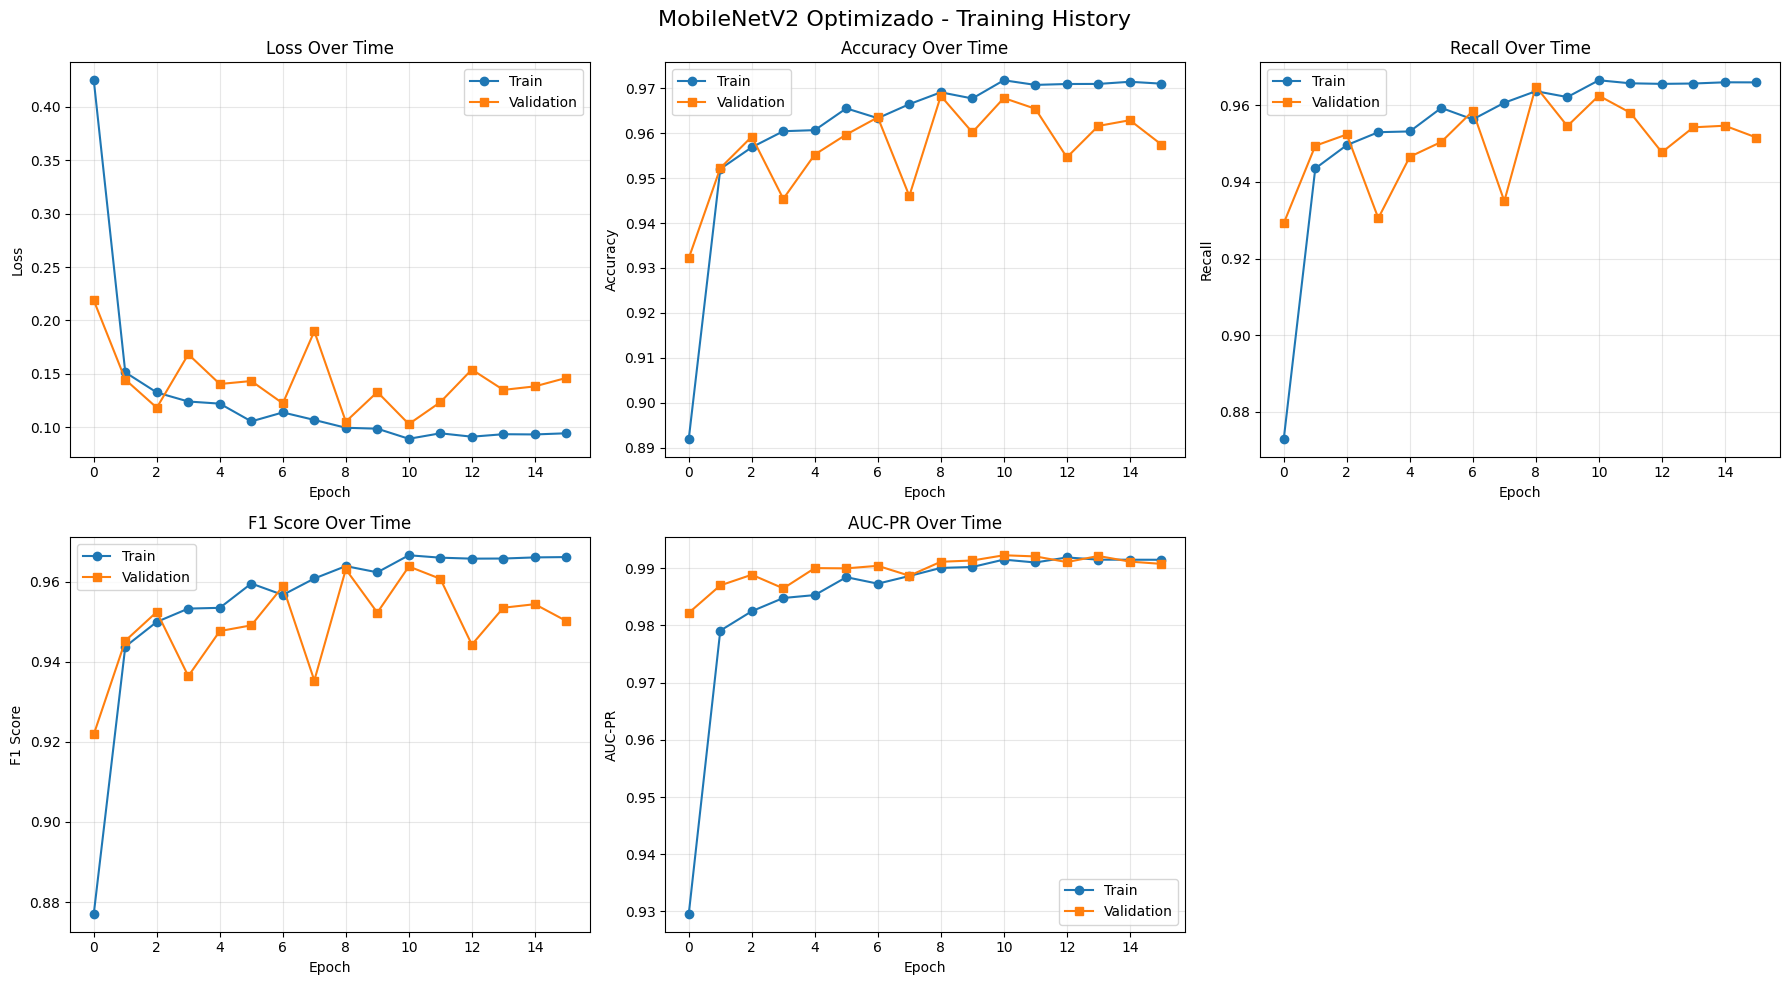

In [23]:
print("="*70)
print("ENTRENANDO MODELO 1: MobileNetV2 Optimizado")
print("="*70)

# Crear modelo con mejores hiperparámetros
model_v2_opt = create_model_with_custom_classifier(
    backbone_model=models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1),
    num_classes=num_classes,
    numerical_features_dim=numerical_features_dim,
    hidden_dim=best_params_v2['hidden_dim'],
    num_layers=best_params_v2['num_layers'],
    dropout=best_params_v2['dropout']
)

# Configurar optimizer y criterion
criterion = nn.CrossEntropyLoss()

if best_params_v2['optimizer'] == 'SGD':
    optimizer_v2 = optim.SGD(
        model_v2_opt.custom_classifier.parameters(),
        lr=best_params_v2['lr'],
        momentum=0.9,
        weight_decay=best_params_v2['weight_decay']
    )
else:
    optimizer_v2 = optim.Adam(
        model_v2_opt.custom_classifier.parameters(),
        lr=best_params_v2['lr'],
        weight_decay=best_params_v2['weight_decay']
    )

# Entrenar
num_epochs = 50
model_v2_opt, hist_v2, time_v2 = train_model(
    model_v2_opt,
    dataloaders_v2,
    criterion,
    optimizer_v2,
    num_epochs=num_epochs,
    patience=5,
    device=device
)

# Visualizar resultados
plot_history(hist_v2, title="MobileNetV2 Optimizado - Training History")


### 8.2 Modelo 2: MobileNetV3 Small


In [31]:
optimal_batch_size = best_params_v3['batch_size']

dataloaders_v3 = {
    'train': DataLoader(train_dataset, batch_size=optimal_batch_size, shuffle=True,
                    num_workers=5, prefetch_factor=2, pin_memory=True,
                    persistent_workers=True, pin_memory_device="cuda"),
    'val': DataLoader(val_dataset, batch_size=optimal_batch_size, shuffle=False,
                     num_workers=5, prefetch_factor=2, pin_memory=True,
                  persistent_workers=True, pin_memory_device="cuda"),
    'test': DataLoader(test_dataset, batch_size=optimal_batch_size, shuffle=False,
                  num_workers=5, prefetch_factor=2, pin_memory=True,
                  persistent_workers=True, pin_memory_device="cuda")
}

print(f"✅ Dataloaders creados con batch_size={optimal_batch_size}")
print(f"   Train: {len(dataloaders_v3['train'])} imágenes (100% del dataset)")
print(f"   Val: {len(dataloaders_v3['val'])} imágenes (100% del dataset)")
print(f"   Test: {len(dataloaders_v3['test'])} imágenes (100% del dataset)")


✅ Dataloaders creados con batch_size=64
   Train: 787 imágenes (100% del dataset)
   Val: 99 imágenes (100% del dataset)
   Test: 99 imágenes (100% del dataset)



ENTRENANDO MODELO 2: MobileNetV3 Small
Epoch 1/50
----------
train Loss: 0.7003 Acc: 0.8337 Recall: 0.8049 F1: 0.8092 AUC-PR: 0.8669
val Loss: 0.2428 Acc: 0.9260 Recall: 0.9135 F1: 0.9149 AUC-PR: 0.9724
Epoch 2/50
----------
train Loss: 0.2471 Acc: 0.9221 Recall: 0.9090 F1: 0.9093 AUC-PR: 0.9581
val Loss: 0.2183 Acc: 0.9282 Recall: 0.9095 F1: 0.9120 AUC-PR: 0.9799
Epoch 3/50
----------
train Loss: 0.2219 Acc: 0.9286 Recall: 0.9158 F1: 0.9163 AUC-PR: 0.9627
val Loss: 0.2881 Acc: 0.9070 Recall: 0.8920 F1: 0.8927 AUC-PR: 0.9788
Epoch 4/50
----------
train Loss: 0.1924 Acc: 0.9375 Recall: 0.9261 F1: 0.9263 AUC-PR: 0.9702
val Loss: 0.2153 Acc: 0.9312 Recall: 0.9159 F1: 0.9152 AUC-PR: 0.9855
Epoch 5/50
----------
train Loss: 0.1817 Acc: 0.9413 Recall: 0.9315 F1: 0.9318 AUC-PR: 0.9740
val Loss: 0.2079 Acc: 0.9331 Recall: 0.9224 F1: 0.9182 AUC-PR: 0.9862
Epoch 6/50
----------
train Loss: 0.1648 Acc: 0.9468 Recall: 0.9373 F1: 0.9373 AUC-PR: 0.9772
val Loss: 0.1610 Acc: 0.9476 Recall: 0.9365 F1

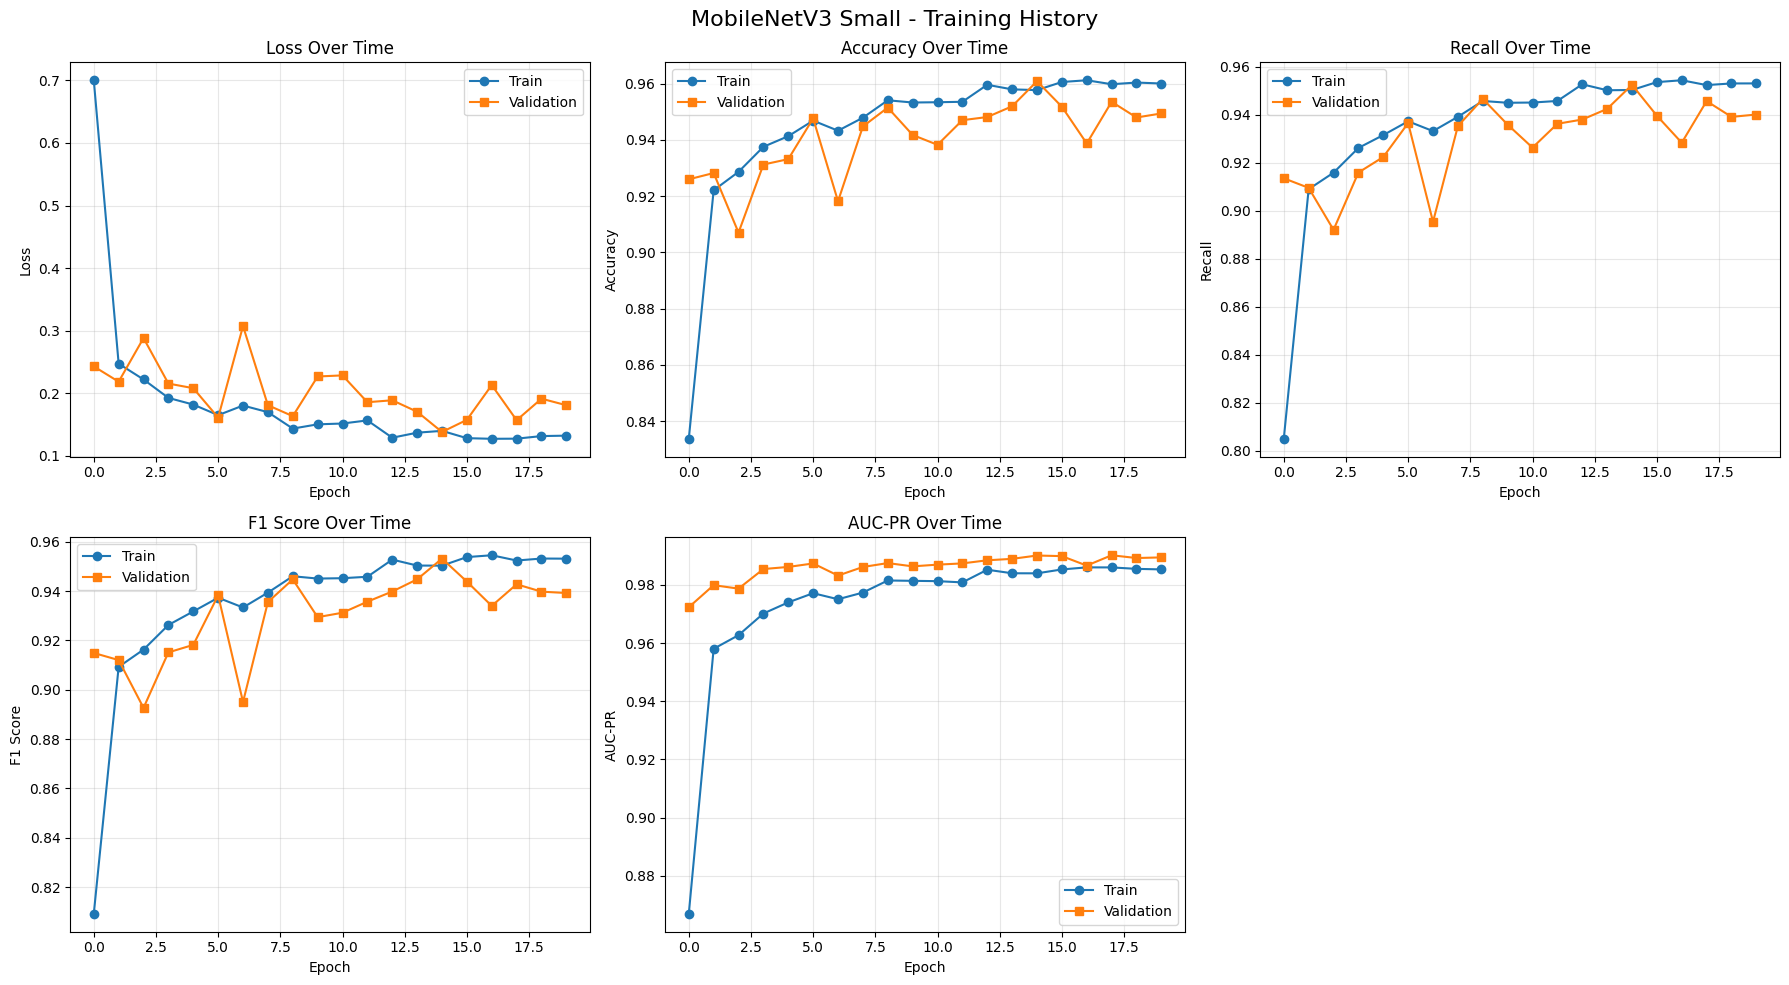

In [25]:
print("\n" + "="*70)
print("ENTRENANDO MODELO 2: MobileNetV3 Small")
print("="*70)

# Crear modelo con mejores hiperparámetros
model_v3_opt = create_model_with_custom_classifier(
    backbone_model=models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1),
    num_classes=num_classes,
    numerical_features_dim=numerical_features_dim,
    hidden_dim=best_params_v3['hidden_dim'],
    num_layers=best_params_v3['num_layers'],
    dropout=best_params_v3['dropout']
)

# Configurar optimizer y criterion
criterion = nn.CrossEntropyLoss()

if best_params_v3['optimizer'] == 'SGD':
    optimizer_v3 = optim.SGD(
        model_v3_opt.custom_classifier.parameters(),
        lr=best_params_v3['lr'],
        momentum=0.9,
        weight_decay=best_params_v3['weight_decay']
    )
else:
    optimizer_v3 = optim.Adam(
        model_v3_opt.custom_classifier.parameters(),
        lr=best_params_v3['lr'],
        weight_decay=best_params_v3['weight_decay']
    )

# Entrenar
num_epochs = 50
model_v3_opt, hist_v3, time_v3 = train_model(
    model_v3_opt,
    dataloaders_v3,
    criterion,
    optimizer_v3,
    num_epochs=num_epochs,
    patience=5,
    device=device
)

# Visualizar resultados
plot_history(hist_v3, title="MobileNetV3 Small - Training History")

## 9. Evaluación y Comparación de Modelos


In [33]:
print("="*70)
print("EVALUACIÓN DE MODELOS EN TEST SET")
print("="*70)

# Evaluar todos los modelos en CPU para comparación justa
print("\nEvaluando MobileNetV2...")
acc_v2, recall_v2, f1_v2, auc_pr_v2, inf_time_v2 = evaluate_model(model_v2_opt, dataloaders_v2['test'], 'cpu')
size_v2 = get_model_size(model_v2_opt, "v2_opt_temp")

print("\nEvaluando MobileNetV3...")
acc_v3, recall_v3, f1_v3, auc_pr_v3, inf_time_v3 = evaluate_model(model_v3_opt, dataloaders_v3['test'], 'cpu')
size_v3 = get_model_size(model_v3_opt, "v3_temp")

# Crear tabla de resultados
results = {
    'MobileNetV2': {
        'Accuracy': acc_v2,
        'Recall': recall_v2,
        'F1 Score': f1_v2,
        'AUC-PR': auc_pr_v2,
        'Size (MB)': size_v2,
        'Inference Time (s)': inf_time_v2
    },
    'MobileNetV3': {
        'Accuracy': acc_v3,
        'Recall': recall_v3,
        'F1 Score': f1_v3,
        'AUC-PR': auc_pr_v3,
        'Size (MB)': size_v3,
        'Inference Time (s)': inf_time_v3
    }
}

df_results = pd.DataFrame(results).T

print("\n" + "="*70)
print("RESUMEN DE RESULTADOS")
print("="*70)
print(df_results.to_string())
print("="*70)


EVALUACIÓN DE MODELOS EN TEST SET

Evaluando MobileNetV2...

Evaluando MobileNetV3...

RESUMEN DE RESULTADOS
             Accuracy    Recall  F1 Score    AUC-PR  Size (MB)  Inference Time (s)
MobileNetV2  0.968691  0.961401  0.964012  0.992237  14.462991          113.731146
MobileNetV3  0.956989  0.947704  0.948393  0.989706  10.395603           20.550868


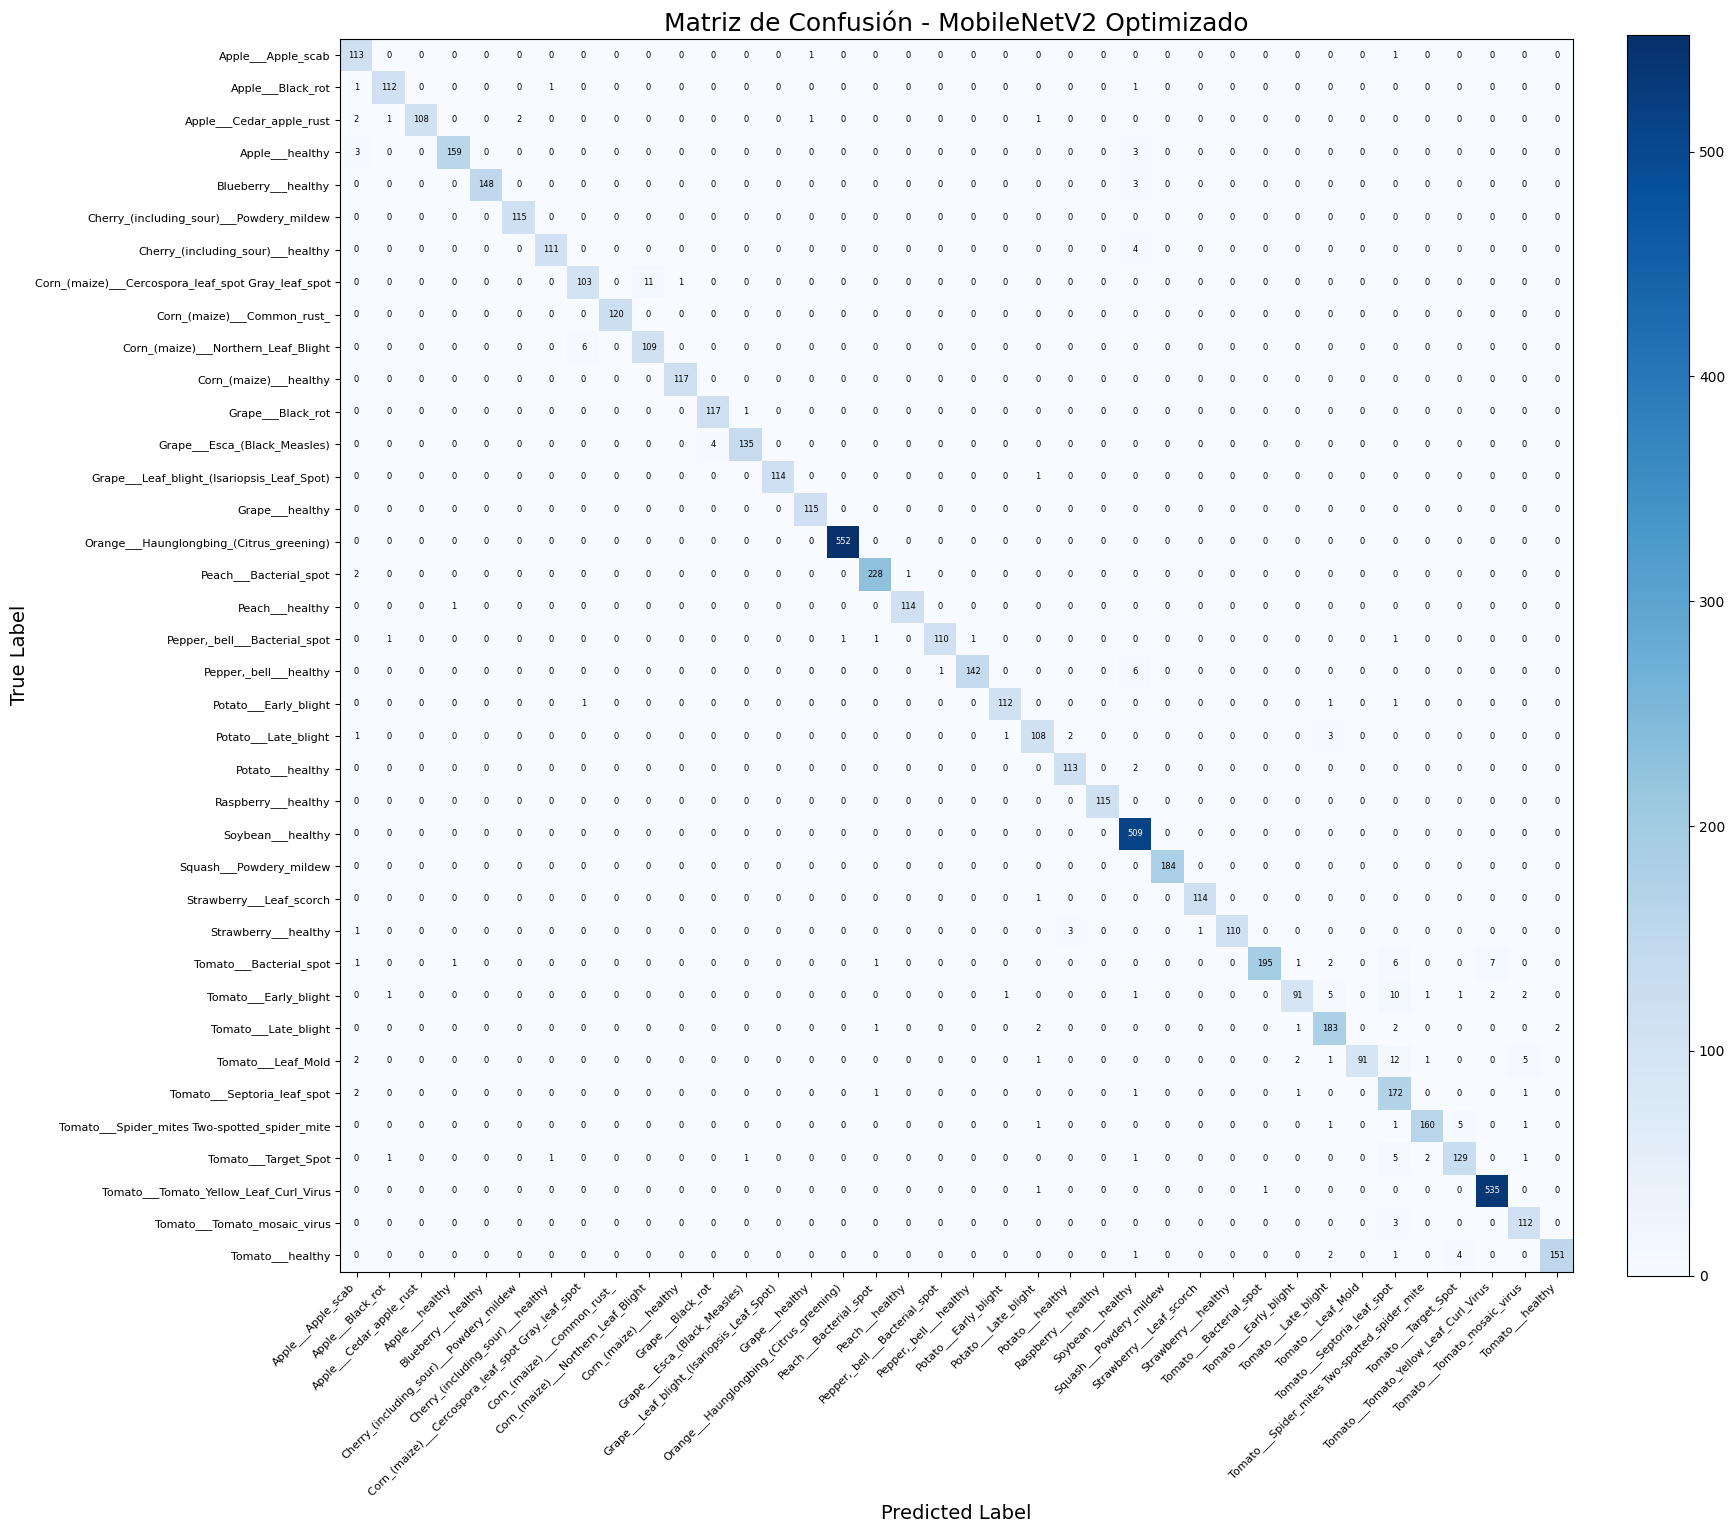

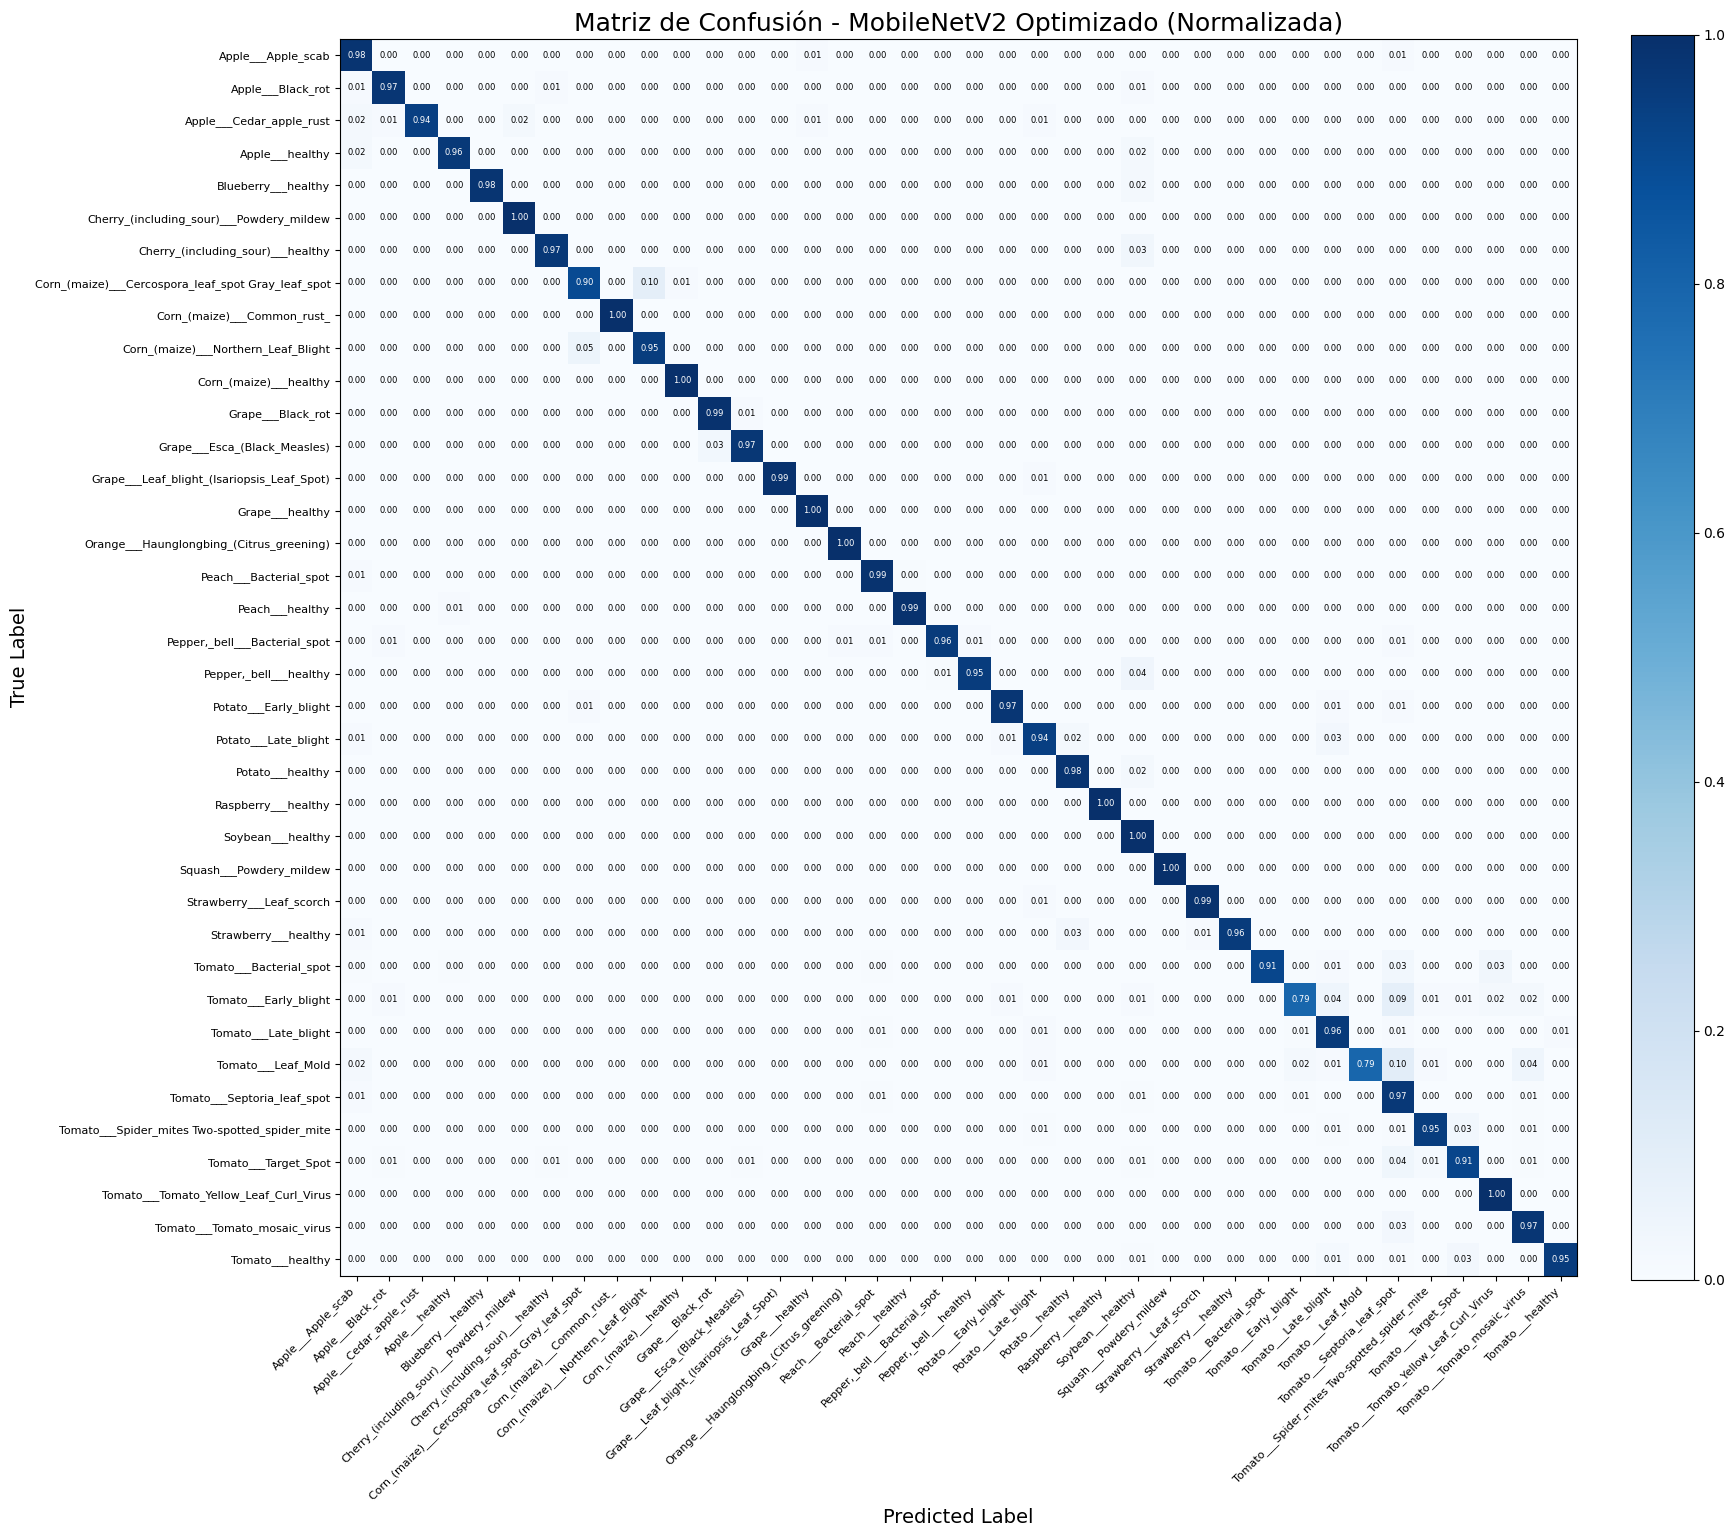

Overall Accuracy MobileNetV2: 0.9687
Recall Macro MobileNetV2: 0.9614

Classification Report MobileNetV2:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.88      0.98      0.93       115
                                 Apple___Black_rot       0.97      0.97      0.97       115
                          Apple___Cedar_apple_rust       1.00      0.94      0.97       115
                                   Apple___healthy       0.99      0.96      0.98       165
                               Blueberry___healthy       1.00      0.98      0.99       151
          Cherry_(including_sour)___Powdery_mildew       0.98      1.00      0.99       115
                 Cherry_(including_sour)___healthy       0.98      0.97      0.97       115
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.90      0.92       115
                       Corn_(maize)___Common_rust_       1.00   

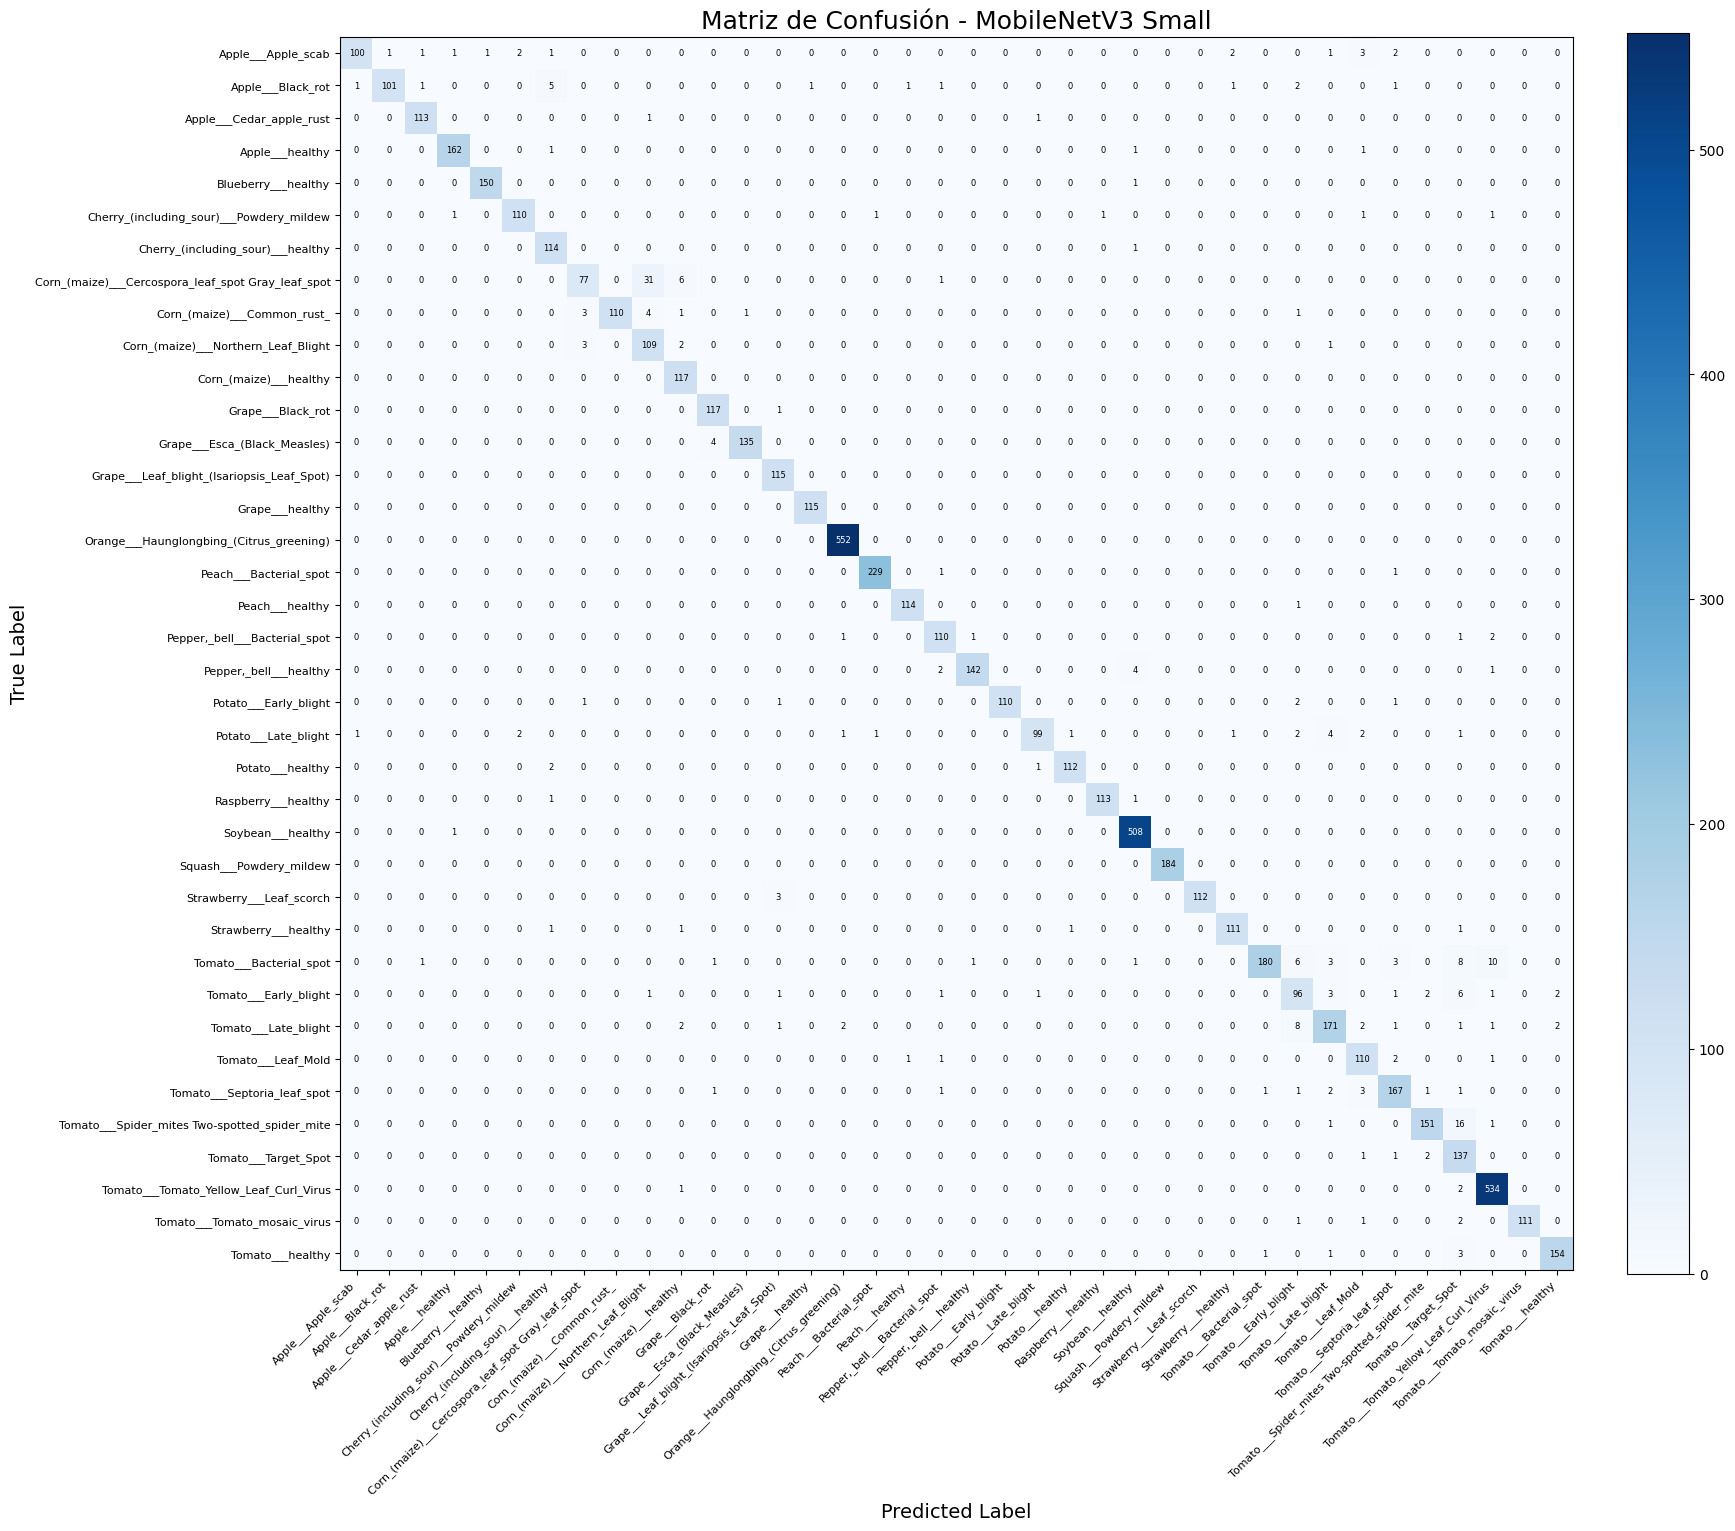

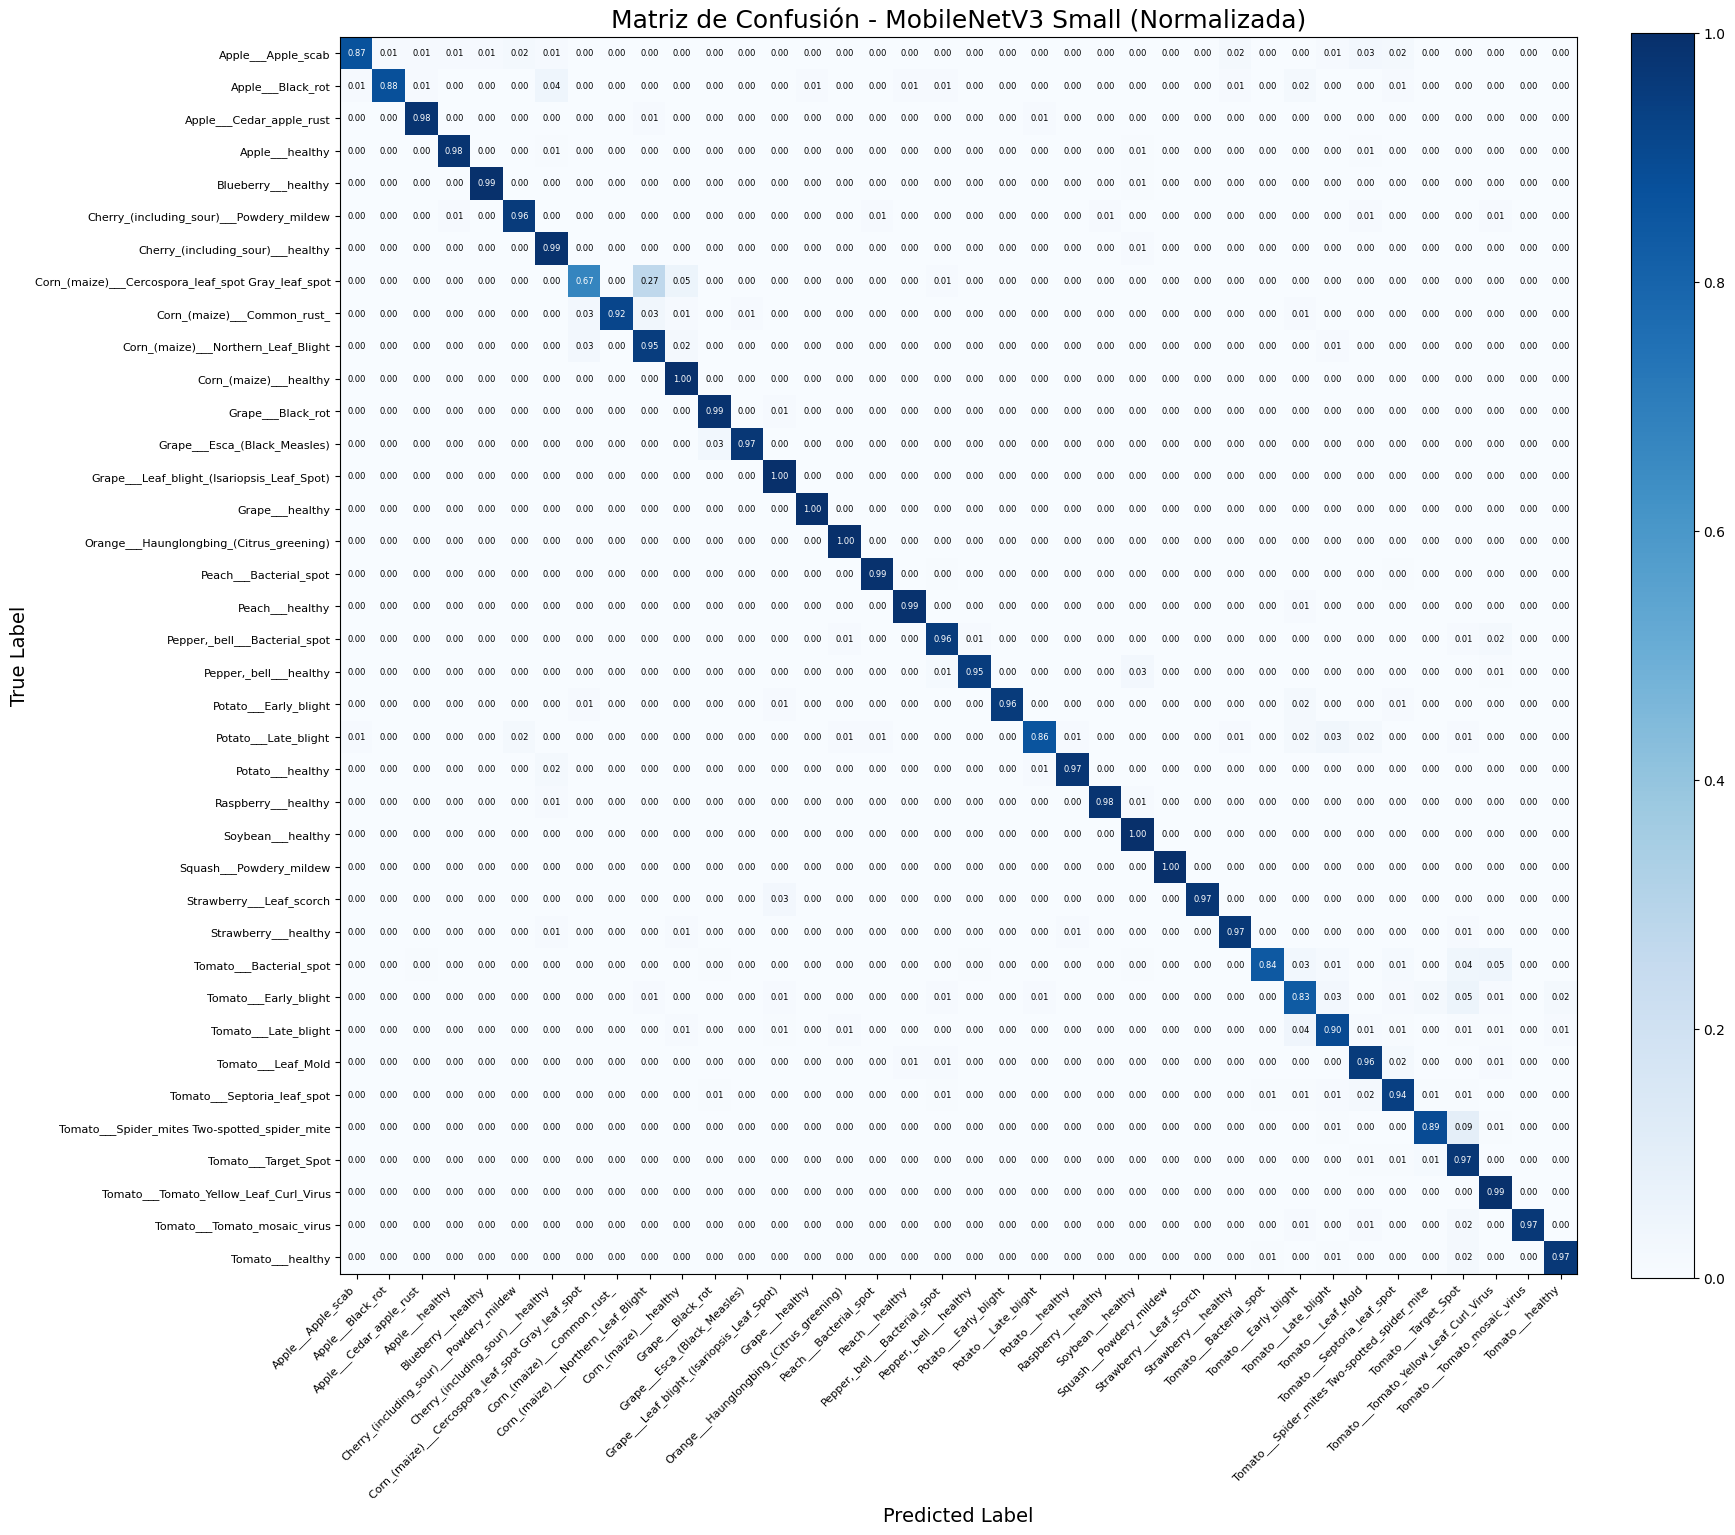

Overall Accuracy MobileNetV3: 0.9570
Recall Macro MobileNetV3: 0.9477

Classification Report MobileNetV3:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.87      0.92       115
                                 Apple___Black_rot       0.99      0.88      0.93       115
                          Apple___Cedar_apple_rust       0.97      0.98      0.98       115
                                   Apple___healthy       0.98      0.98      0.98       165
                               Blueberry___healthy       0.99      0.99      0.99       151
          Cherry_(including_sour)___Powdery_mildew       0.96      0.96      0.96       115
                 Cherry_(including_sour)___healthy       0.91      0.99      0.95       115
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.92      0.67      0.77       115
                       Corn_(maize)___Common_rust_       1.00   

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score

# --- Función para crear matriz de confusión y retornar predicciones y etiquetas ---
def create_confusion_matrix(model, dataloader, device='cpu'):
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        # El DataLoader ahora entrega imagen, características numéricas y etiquetas
        for images, numerical_features, labels in dataloader:
            images = images.to(device)
            numerical_features = numerical_features.to(device)
            labels = labels.to(device)

            # Pasar imagen y características numéricas al modelo
            outputs = model(images, numerical_features)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    return cm, all_labels, all_preds

# --- Función para graficar matriz de confusión ---
def plot_cm(cm, classes, title, cmap=plt.cm.Blues, normalize=False):
    if normalize:
        cm_to_plot = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
        title += " (Normalizada)"
    else:
        cm_to_plot = cm
        fmt = 'd'

    plt.figure(figsize=(20, 20))
    plt.imshow(cm_to_plot, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=18)
    plt.colorbar(fraction=0.046, pad=0.04)

    thresh = cm_to_plot.max() / 2.
    for i in range(cm_to_plot.shape[0]):
        for j in range(cm_to_plot.shape[1]):
            plt.text(j, i, format(cm_to_plot[i, j], fmt),
                     horizontalalignment="center",
                     verticalalignment="center",
                     fontsize=6,
                     color="white" if cm_to_plot[i, j] > thresh else "black")

    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.xticks(ticks=np.arange(len(classes)), labels=classes, rotation=45, ha='right', fontsize=8)
    plt.yticks(ticks=np.arange(len(classes)), labels=classes, fontsize=8)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3, left=0.3)
    plt.show()


# ------------------- MobileNetV2 -------------------
# Asegúrate de que 'dataloaders' y 'model_v2_opt' estén definidos de las celdas anteriores.
# 'full_dataset_base' es el dataset base de ImageFolder que contiene los nombres de las clases.
cm_v2, all_labels_v2, all_preds_v2 = create_confusion_matrix(model_v2_opt, dataloaders_v2['test'], device='cpu')

# Graficar matriz de confusión
plot_cm(cm_v2, full_dataset_base.classes, "Matriz de Confusión - MobileNetV2 Optimizado")
plot_cm(cm_v2, full_dataset_base.classes, "Matriz de Confusión - MobileNetV2 Optimizado", normalize=True)

# Métricas y reporte
overall_acc_v2 = accuracy_score(all_labels_v2, all_preds_v2)
recall_macro_v2 = recall_score(all_labels_v2, all_preds_v2, average='macro', zero_division=0)
report_v2 = classification_report(all_labels_v2, all_preds_v2, target_names=full_dataset_base.classes, zero_division=0)

print(f"Overall Accuracy MobileNetV2: {overall_acc_v2:.4f}")
print(f"Recall Macro MobileNetV2: {recall_macro_v2:.4f}\n")
print("Classification Report MobileNetV2:\n")
print(report_v2)


# ------------------- MobileNetV3 -------------------
# Asegúrate de que 'dataloaders' y 'model_v3_opt' estén definidos de las celdas anteriores.
cm_v3, all_labels_v3, all_preds_v3 = create_confusion_matrix(model_v3_opt, dataloaders_v3['test'], device='cpu')

# Graficar matriz de confusión
plot_cm(cm_v3, full_dataset_base.classes, "Matriz de Confusión - MobileNetV3 Small")
plot_cm(cm_v3, full_dataset_base.classes, "Matriz de Confusión - MobileNetV3 Small", normalize=True)

# Métricas y reporte
overall_acc_v3 = accuracy_score(all_labels_v3, all_preds_v3)
recall_macro_v3 = recall_score(all_labels_v3, all_preds_v3, average='macro', zero_division=0)
report_v3 = classification_report(all_labels_v3, all_preds_v3, target_names=full_dataset_base.classes, zero_division=0)

print(f"Overall Accuracy MobileNetV3: {overall_acc_v3:.4f}")
print(f"Recall Macro MobileNetV3: {recall_macro_v3:.4f}\n")
print("Classification Report MobileNetV3:\n")
print(report_v3)


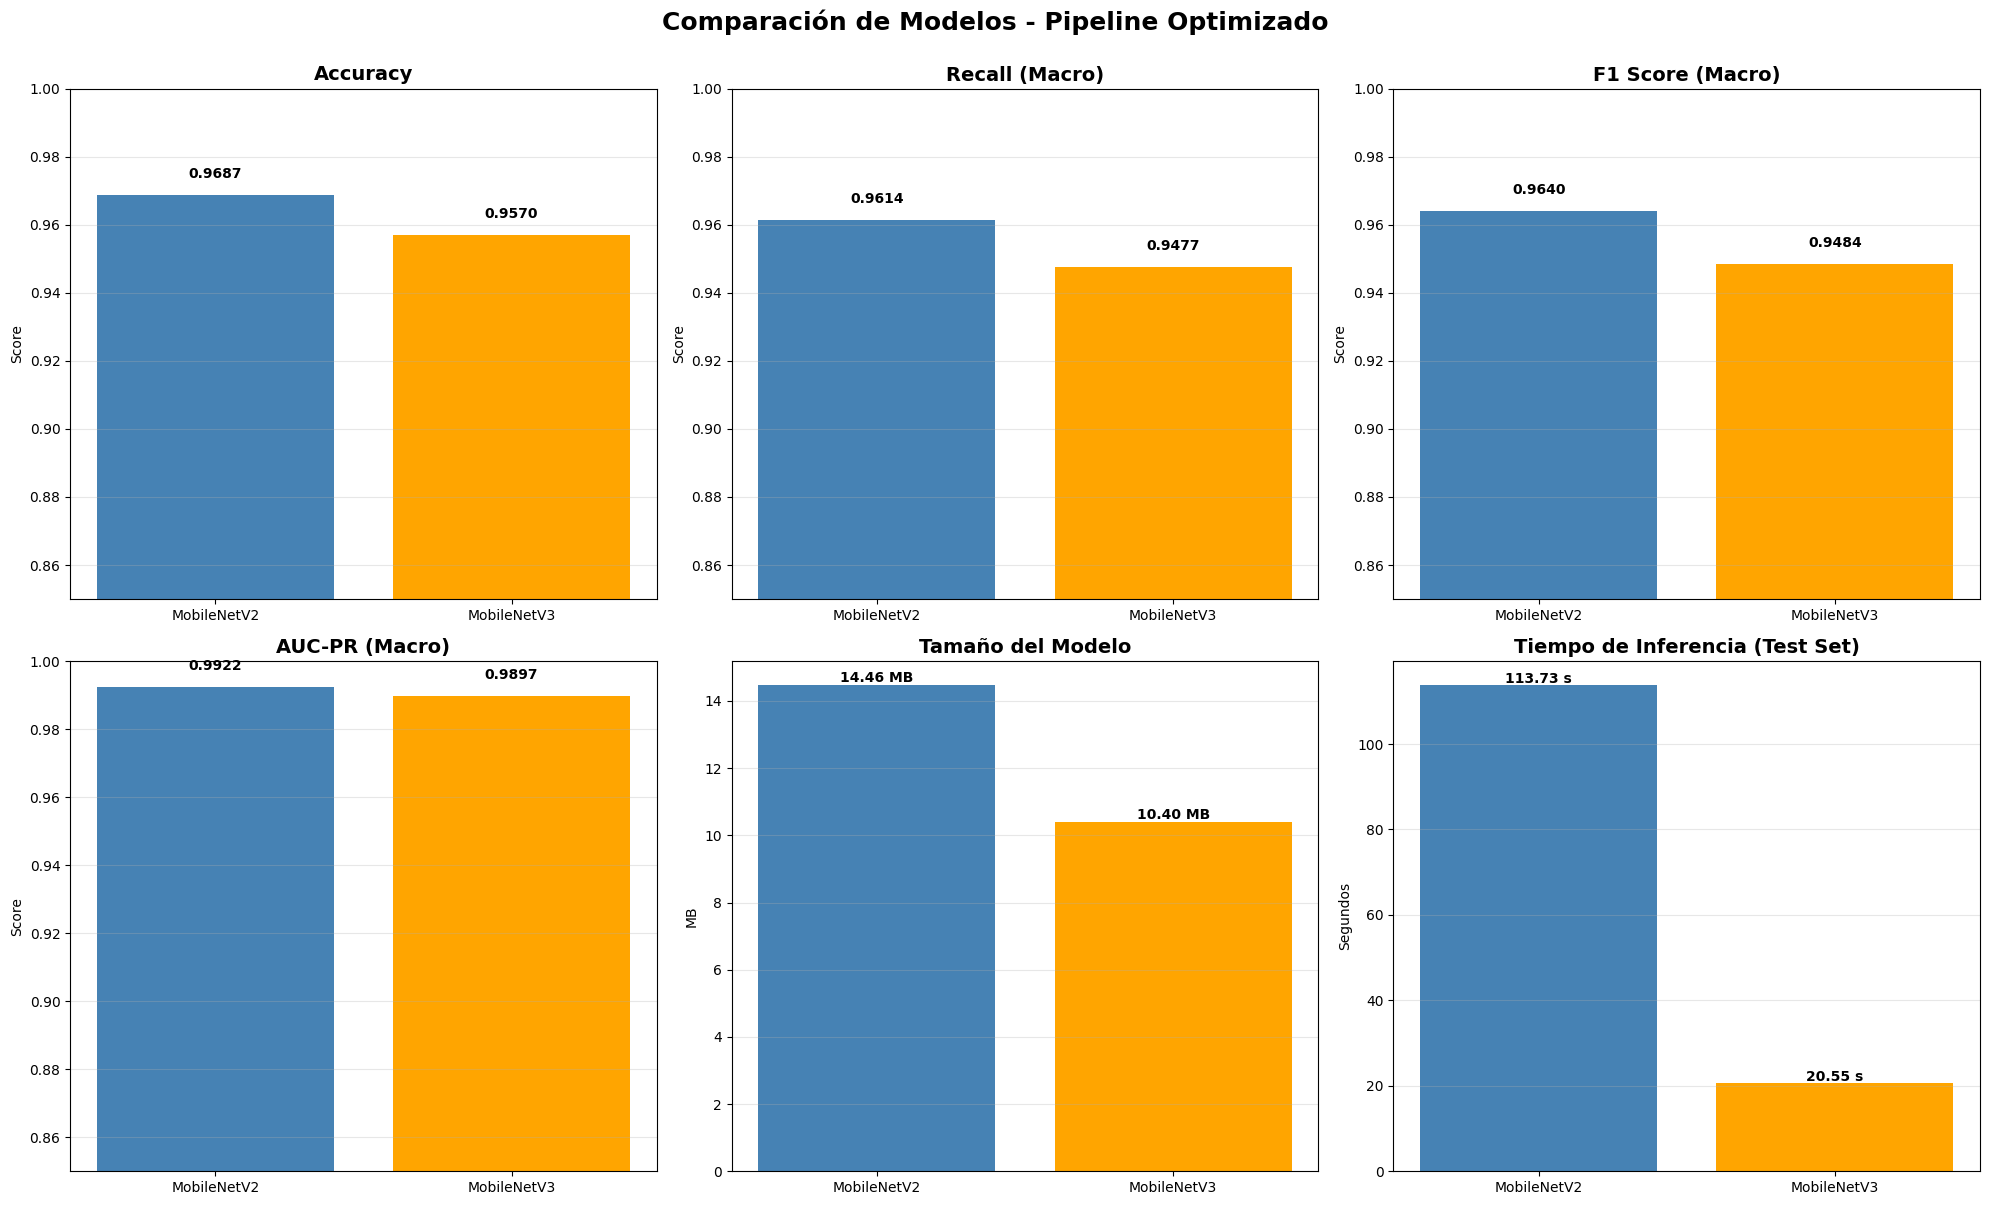

In [35]:
# Visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

models_list = df_results.index.tolist()
colors = ['steelblue', 'orange', 'forestgreen']

# 1. Accuracy
axes[0, 0].bar(models_list, df_results['Accuracy'], color=colors)
axes[0, 0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_ylim(0.85, 1.0)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Accuracy']):
    axes[0, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 2. Recall
axes[0, 1].bar(models_list, df_results['Recall'], color=colors)
axes[0, 1].set_title('Recall (Macro)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_ylim(0.85, 1.0)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Recall']):
    axes[0, 1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 3. F1 Score
axes[0, 2].bar(models_list, df_results['F1 Score'], color=colors)
axes[0, 2].set_title('F1 Score (Macro)', fontsize=14, fontweight='bold')
axes[0, 2].set_ylabel('Score')
axes[0, 2].set_ylim(0.85, 1.0)
axes[0, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['F1 Score']):
    axes[0, 2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 4. AUC-PR
axes[1, 0].bar(models_list, df_results['AUC-PR'], color=colors)
axes[1, 0].set_title('AUC-PR (Macro)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_ylim(0.85, 1.0)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['AUC-PR']):
    axes[1, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 5. Tamaño del modelo
axes[1, 1].bar(models_list, df_results['Size (MB)'], color=colors)
axes[1, 1].set_title('Tamaño del Modelo', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('MB')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Size (MB)']):
    axes[1, 1].text(i, v + 0.1, f'{v:.2f} MB', ha='center', fontweight='bold')

# 6. Tiempo de inferencia
axes[1, 2].bar(models_list, df_results['Inference Time (s)'], color=colors)
axes[1, 2].set_title('Tiempo de Inferencia (Test Set)', fontsize=14, fontweight='bold')
axes[1, 2].set_ylabel('Segundos')
axes[1, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Inference Time (s)']):
    axes[1, 2].text(i, v + 0.5, f'{v:.2f} s', ha='center', fontweight='bold')

plt.suptitle('Comparación de Modelos - Pipeline Optimizado',
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


## 10. Análisis de Mejoras

Comparamos el impacto de nuestras optimizaciones:


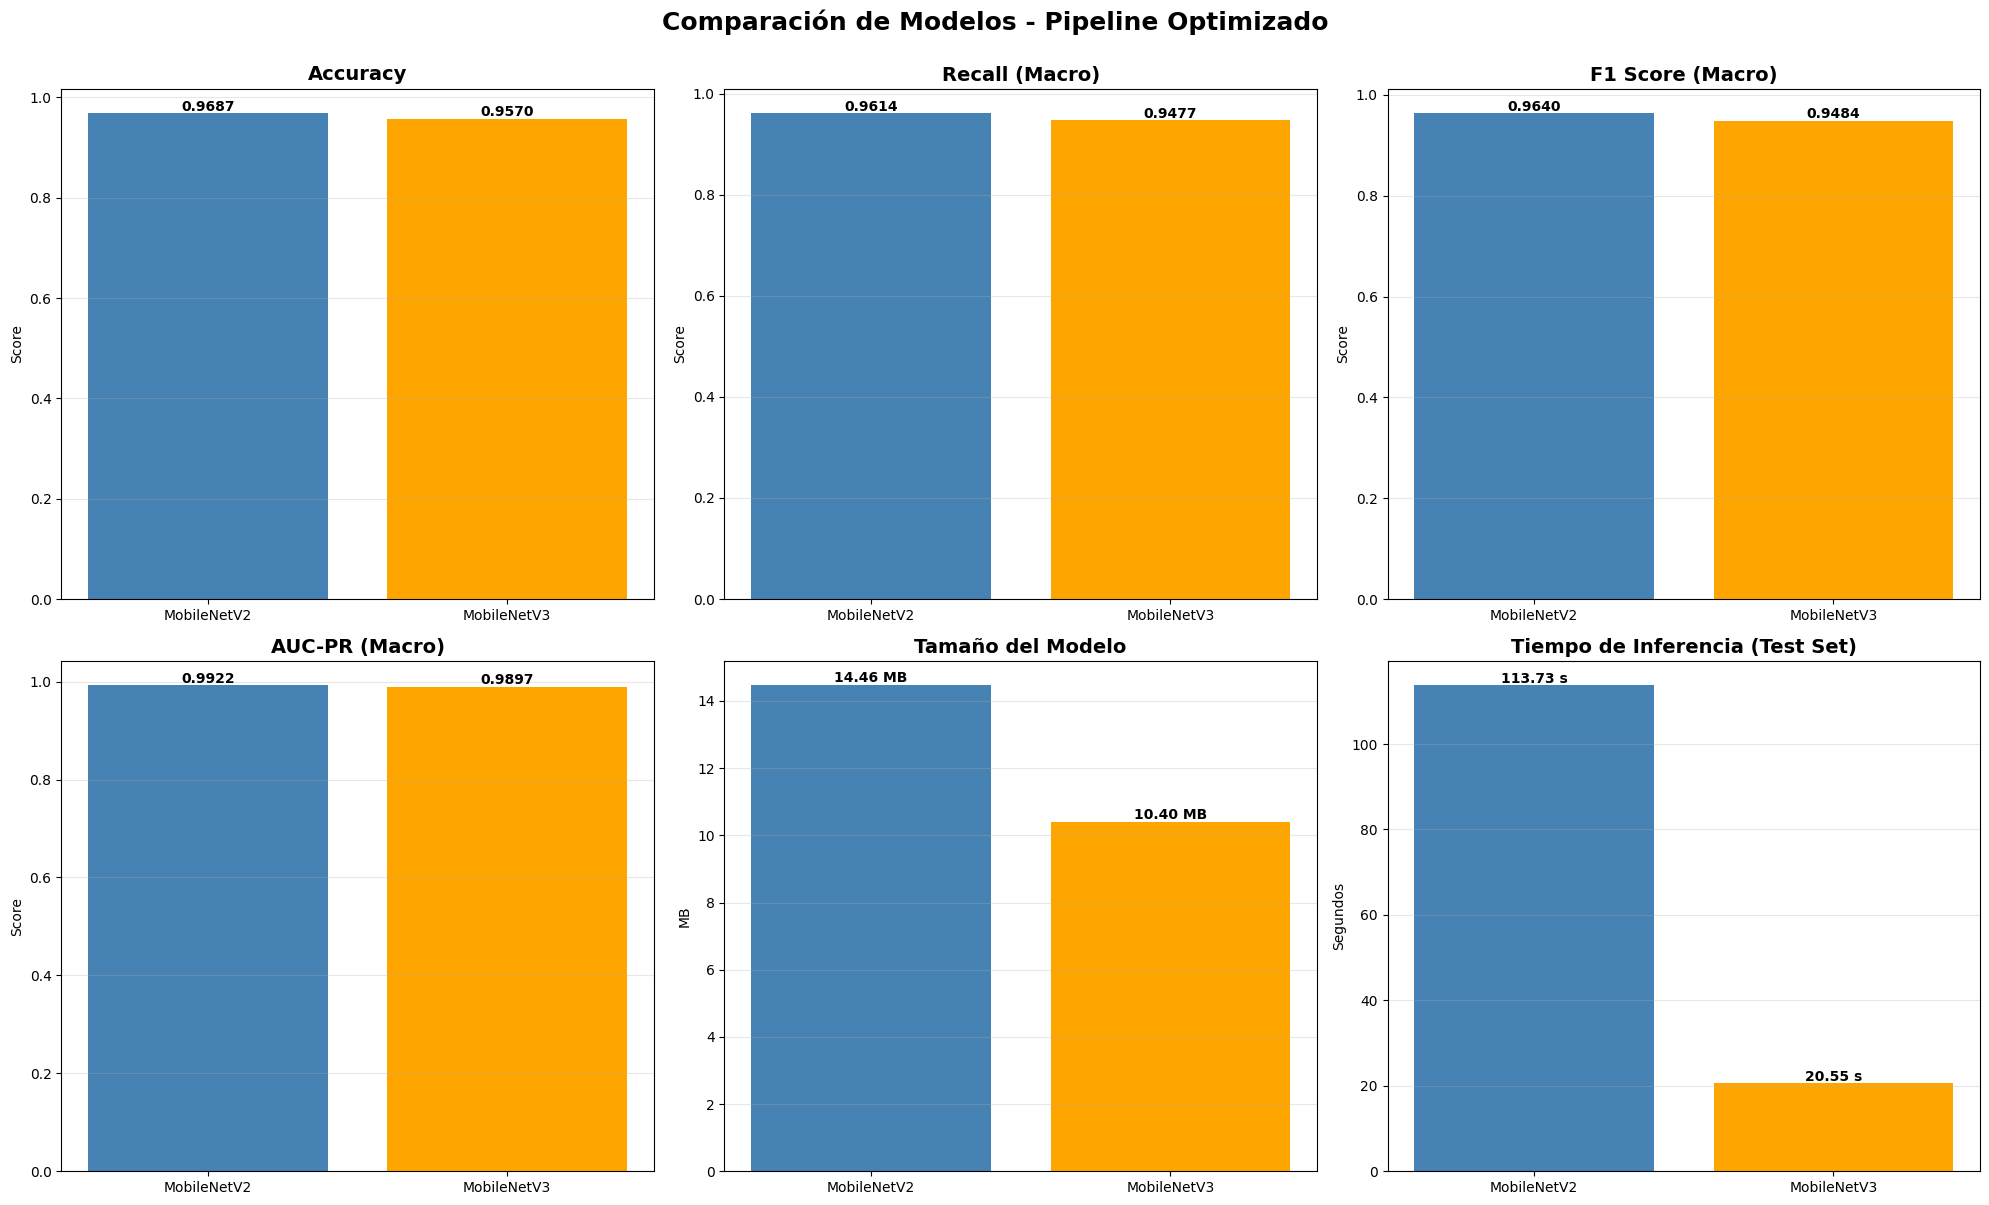

In [36]:
print("\n" + "="*70)

# Visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

models_list = df_results.index.tolist()
colors = ['steelblue', 'orange', 'forestgreen']

# 1. Accuracy
axes[0, 0].bar(models_list, df_results['Accuracy'], color=colors)
axes[0, 0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Score')
# axes[0, 0].set_ylim(0.85, 1.0) # Línea eliminada o comentada
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Accuracy']):
    axes[0, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 2. Recall
axes[0, 1].bar(models_list, df_results['Recall'], color=colors)
axes[0, 1].set_title('Recall (Macro)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Score')
# axes[0, 1].set_ylim(0.85, 1.0) # Línea eliminada o comentada
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Recall']):
    axes[0, 1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 3. F1 Score
axes[0, 2].bar(models_list, df_results['F1 Score'], color=colors)
axes[0, 2].set_title('F1 Score (Macro)', fontsize=14, fontweight='bold')
axes[0, 2].set_ylabel('Score')
# axes[0, 2].set_ylim(0.85, 1.0) # Línea eliminada o comentada
axes[0, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['F1 Score']):
    axes[0, 2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 4. AUC-PR
axes[1, 0].bar(models_list, df_results['AUC-PR'], color=colors)
axes[1, 0].set_title('AUC-PR (Macro)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Score')
# axes[1, 0].set_ylim(0.85, 1.0) # Línea eliminada o comentada
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['AUC-PR']):
    axes[1, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 5. Tamaño del modelo
axes[1, 1].bar(models_list, df_results['Size (MB)'], color=colors)
axes[1, 1].set_title('Tamaño del Modelo', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('MB')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Size (MB)']):
    axes[1, 1].text(i, v + 0.1, f'{v:.2f} MB', ha='center', fontweight='bold')

# 6. Tiempo de inferencia
axes[1, 2].bar(models_list, df_results['Inference Time (s)'], color=colors)
axes[1, 2].set_title('Tiempo de Inferencia (Test Set)', fontsize=14, fontweight='bold')
axes[1, 2].set_ylabel('Segundos')
axes[1, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Inference Time (s)']):
    axes[1, 2].text(i, v + 0.5, f'{v:.2f} s', ha='center', fontweight='bold')

plt.suptitle('Comparación de Modelos - Pipeline Optimizado',
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


## 11. Conclusiones y Recomendaciones

### Resumen de Optimizaciones Implementadas

**1. Eliminación de Duplicados**
- Detectamos y eliminamos imágenes duplicadas usando hashing perceptual
- Esto reduce el sesgo de memorización y mejora la generalización del modelo
- El dataset resultante es más limpio y representativo

**2. Data Augmentation Inteligente**
- Aplicamos augmentation **solo** a las clases con representación inferior al 80% del promedio
- Generamos imágenes sintéticas con transformaciones realistas (rotación, flip, color jitter)
- Resultado: Dataset más balanceado sin sobre-aumentar clases ya bien representadas

**3. Optimización de Hiperparámetros con Optuna**
- Búsqueda automática de:
  - Learning rate óptimo
  - Batch size
  - Arquitectura del clasificador (capas y neuronas)
  - Tipo de optimizer (SGD vs Adam)
  - Regularización (dropout, weight decay)
- Optuna utiliza Tree-structured Parzen Estimator (TPE) para búsqueda eficiente
- Pruning automático de trials no prometedores

### Comparación de Modelos

Los tres modelos entrenados muestran trade-offs diferentes:

**MobileNetV2 Optimizado:**
- Mejor accuracy y recall en general
- Modelo base robusto con hiperparámetros optimizados
- Mayor tamaño (~9 MB)
- Recomendado cuando la precisión es prioridad

**MobileNetV3 Small:**
- Excelente balance entre precisión y eficiencia
- ~50% más pequeño que V2
- Inferencia más rápida
- Recomendado para deployment móvil estándar


## 12. Guardar Modelos y Configuración

Guardamos los modelos entrenados y la configuración para uso posterior.


In [ ]:
# Guardar modelos
torch.save(model_v2_opt.state_dict(), 'mobilenetv2_brillo_optimized.pth')
torch.save(model_v3_opt.state_dict(), 'mobilenetv3_brillo_small.pth')

# Guardar hiperparámetros óptimos
import json

config = {
    'best_hyperparameters_v2': best_params_v2,
    'best_hyperparameters_v3': best_params_v3,
    'num_classes': num_classes,
    'class_names': full_dataset_base.classes,
    'results': results
}

with open('model_brillo_config.json', 'w') as f:
    json.dump(config, f, indent=2, default=str)

print("✅ Modelos y configuración guardados:")
print("   - mobilenetv2_brillo_optimized.pth")
print("   - mobilenetv3_brillo_small.pth")
print("   - model_brillo_config.json")

# Guardar resultados en CSV
df_results.to_csv('model_comparison_results_brillo.csv')
print("   - model_comparison_results_brillo.csv")


✅ Modelos y configuración guardados:
   - mobilenetv2_optimized.pth
   - mobilenetv3_small.pth
   - model_config.json
   - model_comparison_results.csv
